In [1]:
# ============================================================
# JOB MARKET & SKILLS DEMAND ANALYTICS
# COMPLETE DATA CLEANING PIPELINE
# Dataset: indian_tech_jobs_2026.csv
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


# ============================================================
# 2. LOAD DATA
# ============================================================

file_path = "indian_tech_jobs_2026.csv"

raw = pd.read_csv(file_path)

# Keep a separate working copy
df = raw.copy()

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ============================================================
# 3. INITIAL DATA PROFILING
# ============================================================

print("\n" + "=" * 70)
print("INITIAL DATA PROFILING")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("\nRandom Sample:")
display(df.sample(5, random_state=42))

print("\nStatistical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include="object"))


# ============================================================
# 4. STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("\nStandardized Column Names:")
print(df.columns.tolist())


# ============================================================
# 5. CREATE BEFORE-CLEANING QUALITY REPORT
# ============================================================

def quality_report(data):
    return pd.DataFrame({
        "data_type": data.dtypes.astype(str),
        "missing_count": data.isna().sum(),
        "missing_percentage": (
            data.isna().mean() * 100
        ).round(2),
        "unique_count": data.nunique(dropna=True)
    }).sort_values(
        "missing_percentage",
        ascending=False
    )


quality_before = quality_report(df)

print("\n" + "=" * 70)
print("QUALITY REPORT BEFORE CLEANING")
print("=" * 70)

display(quality_before)


# ============================================================
# 6. CHECK EXACT DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]

    print("\nDuplicate rows:")
    display(duplicate_rows.head())

    df = df.drop_duplicates()

else:
    print("No exact duplicate rows found.")


# ============================================================
# 7. CHECK BUSINESS KEY: JOB_ID
# ============================================================

print("\n" + "=" * 70)
print("JOB ID VALIDATION")
print("=" * 70)

print("Missing job IDs:", df["job_id"].isna().sum())
print("Duplicate job IDs:", df["job_id"].duplicated().sum())
print("Unique job IDs:", df["job_id"].nunique())

# job_id should be unique
if df["job_id"].isna().sum() > 0:
    df = df.dropna(subset=["job_id"])

if df["job_id"].duplicated().sum() > 0:
    df = df.drop_duplicates(
        subset=["job_id"],
        keep="first"
    )


# ============================================================
# 8. CLEAN TEXT COLUMNS
# IMPORTANT:
# DO NOT LOWERCASE THE ENTIRE DATAFRAME.
# ============================================================

text_columns = df.select_dtypes(
    include=["object", "string"]
).columns

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

print("\nText columns cleaned for whitespace.")


# ============================================================
# 9. HANDLE PLACEHOLDER VALUES
# ============================================================

# These columns contain "Not Available" / "Not Disclosed"
# where missing information should be treated as missing.

missing_placeholder_columns = [
    "company_name",
    "experience_raw",
    "skills_required",
    "job_description",
    "posted_date_raw"
]

for col in missing_placeholder_columns:
    if col in df.columns:
        df[col] = df[col].replace(
            [
                "Not Available",
                "Not available",
                "NOT AVAILABLE",
                "Not Disclosed",
                "Not disclosed",
                "NOT DISCLOSED"
            ],
            pd.NA
        )

print("\nPlaceholder values converted to missing values.")


# ============================================================
# 10. DO NOT CONVERT SALARY "NOT DISCLOSED" TO ZERO/NA
# ============================================================

# salary_raw contains meaningful values such as:
# "Not Disclosed"
# "Unpaid"
# "15-30 Lacs PA"
#
# We preserve salary_raw.
# salary_min_lpa and salary_max_lpa are used for
# quantitative salary analysis.


# ============================================================
# 11. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "job_id",
    "company_rating",
    "experience_min_yrs",
    "experience_max_yrs",
    "salary_min_lpa",
    "salary_max_lpa",
    "skills_count",
    "salary_midpoint_lpa",
    "days_since_posted"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ============================================================
# 12. CONVERT BOOLEAN COLUMNS
# ============================================================

boolean_columns = [
    "salary_disclosed",
    "is_senior",
    "is_fresher_friendly",
    "salary_negotiable"
]

for col in boolean_columns:
    if col in df.columns:
        df[col] = df[col].astype("boolean")


# ============================================================
# 13. CLEAN CATEGORICAL COLUMNS
# ============================================================

categorical_columns = [
    "role_category",
    "work_mode",
    "company_size_bucket",
    "salary_tier",
    "experience_tier",
    "primary_city",
    "skill_domain",
    "scraped_city"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )


# ============================================================
# 14. STANDARDIZE CITY NAMES
# ============================================================

city_mapping = {
    "Bangalore": "Bengaluru",
    "Bengaluru": "Bengaluru",
    "Gurgaon": "Gurugram",
    "Gurugram": "Gurugram"
}

df["primary_city_clean"] = (
    df["primary_city"]
    .replace(city_mapping)
)

df["scraped_city_clean"] = (
    df["scraped_city"]
    .replace(city_mapping)
)


# ============================================================
# 15. CLEAN WORK MODE
# ============================================================

df["work_mode_clean"] = (
    df["work_mode"]
    .astype("string")
    .str.strip()
    .str.title()
)

# Correct On-Site formatting
df["work_mode_clean"] = df["work_mode_clean"].replace({
    "On-Site": "On-site",
    "On Site": "On-site"
})


# ============================================================
# 16. EXPERIENCE CLEANING
# ============================================================
#
# The original dataset contains some incorrectly parsed values
# such as:
#
# 13 Jun
# 20 Yrs
# 17 May - 15 Aug
# 3 months duration
#
# These should not automatically be interpreted as years of
# experience.


experience_raw = (
    df["experience_raw"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# 16A. Reset derived experience columns
# ------------------------------------------------------------

df["experience_min_clean"] = np.nan
df["experience_max_clean"] = np.nan


# ------------------------------------------------------------
# 16B. Handle Fresher
# ------------------------------------------------------------

fresher_mask = (
    experience_raw
    .str.lower()
    .eq("fresher")
)

df.loc[
    fresher_mask,
    "experience_min_clean"
] = 0

df.loc[
    fresher_mask,
    "experience_max_clean"
] = 0


# ------------------------------------------------------------
# 16C. Extract experience ranges
# Example:
# 5-10 Yrs
# 3 - 8 Yrs
# 10-15 Yrs
# ------------------------------------------------------------

range_pattern = (
    r"^\s*(\d+(?:\.\d+)?)"
    r"\s*-\s*"
    r"(\d+(?:\.\d+)?)"
    r"\s*Yrs?\s*$"
)

experience_ranges = experience_raw.str.extract(
    range_pattern,
    expand=True
)

experience_ranges.columns = [
    "experience_min_extracted",
    "experience_max_extracted"
]

experience_ranges = experience_ranges.apply(
    pd.to_numeric,
    errors="coerce"
)


range_mask = (
    experience_ranges["experience_min_extracted"]
    .notna()
    &
    experience_ranges["experience_max_extracted"]
    .notna()
)

df.loc[
    range_mask,
    "experience_min_clean"
] = experience_ranges.loc[
    range_mask,
    "experience_min_extracted"
]

df.loc[
    range_mask,
    "experience_max_clean"
] = experience_ranges.loc[
    range_mask,
    "experience_max_extracted"
]


# ------------------------------------------------------------
# 16D. Extract single experience values
# Example:
# 3 Yrs
# 15 Yrs
# 20 Yrs
# ------------------------------------------------------------

single_pattern = (
    r"^\s*(\d+(?:\.\d+)?)"
    r"\s*Yrs?\s*$"
)

single_experience = pd.to_numeric(
    experience_raw.str.extract(
        single_pattern,
        expand=False
    ),
    errors="coerce"
)

single_mask = single_experience.notna()

df.loc[
    single_mask,
    "experience_min_clean"
] = single_experience[single_mask]

df.loc[
    single_mask,
    "experience_max_clean"
] = single_experience[single_mask]


# ------------------------------------------------------------
# 16E. Invalid/date-like/duration values remain missing
# ------------------------------------------------------------

invalid_experience_mask = (
    df["experience_min_clean"]
    >
    df["experience_max_clean"]
)

df.loc[
    invalid_experience_mask,
    [
        "experience_min_clean",
        "experience_max_clean"
    ]
] = np.nan


# ============================================================
# 17. EXPERIENCE MIDPOINT
# ============================================================

df["experience_midpoint_clean"] = (
    df["experience_min_clean"]
    +
    df["experience_max_clean"]
) / 2


# ============================================================
# 18. CREATE CLEAN EXPERIENCE TIER
# ============================================================

def assign_experience_tier(row):

    min_exp = row["experience_min_clean"]

    if pd.isna(min_exp):
        return "Not Available"

    if min_exp == 0:
        return "Fresher"

    elif min_exp <= 2:
        return "Junior (0-2 Yrs)"

    elif min_exp <= 5:
        return "Mid (3-5 Yrs)"

    elif min_exp <= 8:
        return "Senior (6-8 Yrs)"

    else:
        return "Lead/Architect (9+ Yrs)"


df["experience_tier_clean"] = df.apply(
    assign_experience_tier,
    axis=1
)


# ============================================================
# 19. CREATE CLEAN SENIOR FLAG
# ============================================================

df["is_senior_clean"] = (
    df["experience_min_clean"] >= 6
)

df["is_senior_clean"] = (
    df["is_senior_clean"]
    .fillna(False)
    .astype(bool)
)


# ============================================================
# 20. SALARY VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("SALARY VALIDATION")
print("=" * 70)

invalid_salary = df[
    (
        df["salary_min_lpa"] < 0
    )
    |
    (
        df["salary_max_lpa"] < 0
    )
    |
    (
        df["salary_min_lpa"]
        >
        df["salary_max_lpa"]
    )
]

print(
    "Invalid salary records:",
    len(invalid_salary)
)

if len(invalid_salary) > 0:
    display(
        invalid_salary[
            [
                "job_id",
                "salary_raw",
                "salary_min_lpa",
                "salary_max_lpa"
            ]
        ].head(20)
    )


# ============================================================
# 21. CREATE CLEAN SALARY MIDPOINT
# ============================================================

# Only calculate salary midpoint for disclosed salaries.
# Do NOT replace undisclosed salary with median/mean.

df["salary_midpoint_clean"] = np.nan

salary_mask = (
    df["salary_disclosed"]
    &
    df["salary_min_lpa"].notna()
    &
    df["salary_max_lpa"].notna()
)

df.loc[
    salary_mask,
    "salary_midpoint_clean"
] = (
    df.loc[salary_mask, "salary_min_lpa"]
    +
    df.loc[salary_mask, "salary_max_lpa"]
) / 2


# ============================================================
# 22. SALARY ANALYSIS DATASET
# ============================================================

salary_df = df[
    df["salary_disclosed"]
    &
    df["salary_midpoint_clean"].notna()
].copy()

print(
    "\nSalary records available for salary analysis:",
    len(salary_df)
)


# ============================================================
# 23. COMPANY RATING VALIDATION
# ============================================================

invalid_rating = df[
    (df["company_rating"] < 0)
    |
    (df["company_rating"] > 5)
]

print(
    "Invalid company ratings:",
    len(invalid_rating)
)


# ============================================================
# 24. DAYS SINCE POSTED VALIDATION
# ============================================================

invalid_days = df[
    df["days_since_posted"] < 0
]

print(
    "Invalid days_since_posted:",
    len(invalid_days)
)


# ============================================================
# 25. PARSE SCRAPED DATE
# ============================================================

df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce"
)

df["scraped_date"] = (
    df["scraped_at"]
    .dt.normalize()
)


# ============================================================
# 26. POSTED DATE RAW
# ============================================================
#
# posted_date_raw contains values such as:
# 1 day ago
# 3+ weeks ago
# Today
# 13 Jun
#
# Therefore, we do NOT force all values through
# pd.to_datetime().
#
# days_since_posted is already provided and is more
# appropriate for quantitative analysis.


# ============================================================
# 27. SKILLS CLEANING
# ============================================================

# Preserve original skills_required.
# Create a separate analytical version.

df["skills_required_clean"] = (
    df["skills_required"]
    .astype("string")
    .str.strip()
)

# Convert unavailable skills to missing
df["skills_required_clean"] = (
    df["skills_required_clean"]
    .replace(
        [
            "Not Available",
            "Not available",
            "NOT AVAILABLE"
        ],
        pd.NA
    )
)


# ============================================================
# 28. CREATE SKILLS AVAILABLE FLAG
# ============================================================

df["skills_available"] = (
    df["skills_required_clean"]
    .notna()
)


# ============================================================
# 29. CREATE SKILL LIST
# ============================================================

skills_series = (
    df["skills_required_clean"]
    .dropna()
    .str.split(",")
    .explode()
    .astype("string")
    .str.strip()
    .str.lower()
)

# Remove empty values
skills_series = skills_series[
    skills_series.notna()
    &
    (skills_series != "")
]

# Remove duplicate skills within the same job
# by using job_id + skill
skill_table = df[
    ["job_id", "skills_required_clean"]
].dropna(
    subset=["skills_required_clean"]
).copy()

skill_table["skill"] = (
    skill_table["skills_required_clean"]
    .str.split(",")
)

skill_table = skill_table.explode("skill")

skill_table["skill"] = (
    skill_table["skill"]
    .astype("string")
    .str.strip()
    .str.lower()
)

skill_table = skill_table[
    skill_table["skill"].notna()
    &
    (skill_table["skill"] != "")
]

skill_table = skill_table.drop_duplicates(
    subset=["job_id", "skill"]
)


# ============================================================
# 30. SKILL DEMAND TABLE
# ============================================================

skill_demand = (
    skill_table
    .groupby("skill")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

print("\nTop 20 Skills:")
display(skill_demand.head(20))


# ============================================================
# 31. VALIDATE SKILLS COUNT
# ============================================================

skills_per_job = (
    skill_table
    .groupby("job_id")
    .size()
    .rename("skills_count_clean")
)

df = df.merge(
    skills_per_job,
    on="job_id",
    how="left"
)

df["skills_count_clean"] = (
    df["skills_count_clean"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 32. JOB DESCRIPTION CLEANING
# ============================================================

df["job_description_clean"] = (
    df["job_description"]
    .astype("string")
    .str.strip()
)

df["job_description_clean"] = (
    df["job_description_clean"]
    .replace(
        [
            "Not Available",
            "Not available",
            "NOT AVAILABLE"
        ],
        pd.NA
    )
)


# ============================================================
# 33. JOB DESCRIPTION AVAILABLE FLAG
# ============================================================

df["job_description_available"] = (
    df["job_description_clean"]
    .notna()
)


# ============================================================
# 34. REMOVE NON-INFORMATIVE COLUMNS
# ============================================================

# salary_negotiable contains only False in this dataset.
# data_source contains only naukri.com.
#
# They do not contribute analytical variation.

columns_to_drop = []

if (
    "salary_negotiable" in df.columns
    and df["salary_negotiable"].nunique(
        dropna=False
    ) <= 1
):
    columns_to_drop.append("salary_negotiable")

if (
    "data_source" in df.columns
    and df["data_source"].nunique(
        dropna=False
    ) <= 1
):
    columns_to_drop.append("data_source")

if columns_to_drop:
    df = df.drop(
        columns=columns_to_drop
    )

print(
    "\nColumns removed as non-informative:",
    columns_to_drop
)


# ============================================================
# 35. OUTLIER DETECTION - SALARY
# ============================================================
#
# DO NOT DELETE salary outliers automatically.
# They may represent legitimate high-paying jobs.
#
# We only create an outlier flag.

if len(salary_df) > 0:

    q1 = salary_df[
        "salary_midpoint_clean"
    ].quantile(0.25)

    q3 = salary_df[
        "salary_midpoint_clean"
    ].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df["salary_outlier_iqr"] = False

    salary_outlier_mask = (
        df["salary_midpoint_clean"] < lower_bound
    ) | (
        df["salary_midpoint_clean"] > upper_bound
    )

    df.loc[
        salary_outlier_mask,
        "salary_outlier_iqr"
    ] = True

    print("\nSalary IQR Outlier Limits:")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    print(
        "Potential salary outliers:",
        df["salary_outlier_iqr"].sum()
    )


# ============================================================
# 36. FEATURE ENGINEERING
# ============================================================

# Job title length
df["job_title_length"] = (
    df["job_title"]
    .astype("string")
    .str.len()
)

# Job title word count
df["job_title_word_count"] = (
    df["job_title"]
    .astype("string")
    .str.split()
    .str.len()
)

# Description length
df["description_length"] = (
    df["job_description_clean"]
    .fillna("")
    .str.len()
)

# Description word count
df["description_word_count"] = (
    df["job_description_clean"]
    .fillna("")
    .str.split()
    .str.len()
)


# ============================================================
# 37. FRESHER / EXPERIENCE VALIDATION
# ============================================================

# Check whether fresher-friendly jobs have valid data

print("\nFresher-friendly jobs:")
print(
    df["is_fresher_friendly"]
    .value_counts(dropna=False)
)


# ============================================================
# 38. FINAL MISSING VALUE REPORT
# ============================================================

quality_after = quality_report(df)

print("\n" + "=" * 70)
print("QUALITY REPORT AFTER CLEANING")
print("=" * 70)

display(quality_after)


# ============================================================
# 39. FINAL DUPLICATE CHECK
# ============================================================

print("\nFinal exact duplicates:")
print(df.duplicated().sum())

print("\nFinal duplicate job IDs:")
print(df["job_id"].duplicated().sum())


# ============================================================
# 40. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

# Job ID
assert df["job_id"].notna().all()
assert df["job_id"].is_unique

# Salary
assert df["salary_min_lpa"].ge(0).all()
assert df["salary_max_lpa"].ge(0).all()

# Company rating
assert df["company_rating"].between(
    0, 5
).all()

# Days since posted
assert df["days_since_posted"].ge(0).all()

# Experience
valid_experience = (
    df["experience_min_clean"].isna()
    |
    df["experience_max_clean"].isna()
    |
    (
        df["experience_min_clean"]
        <=
        df["experience_max_clean"]
    )
)

assert valid_experience.all()

print("✓ Job IDs are valid and unique")
print("✓ Salary values are non-negative")
print("✓ Company ratings are within valid range")
print("✓ Days since posted are valid")
print("✓ Experience ranges are valid")
print("✓ Final validation completed successfully")


# ============================================================
# 41. BEFORE VS AFTER SUMMARY
# ============================================================

before_summary = {
    "rows": len(raw),
    "columns": len(raw.columns),
    "missing_values": int(
        raw.isna().sum().sum()
    ),
    "duplicate_rows": int(
        raw.duplicated().sum()
    )
}

after_summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "missing_values": int(
        df.isna().sum().sum()
    ),
    "duplicate_rows": int(
        df.duplicated().sum()
    )
}

comparison = pd.DataFrame(
    [before_summary, after_summary],
    index=["Before Cleaning", "After Cleaning"]
)

print("\n" + "=" * 70)
print("BEFORE VS AFTER CLEANING")
print("=" * 70)

display(comparison)


# ============================================================
# 42. CREATE CLEANING LOG
# ============================================================

cleaning_log = pd.DataFrame({
    "Step": [
        "Initial dataset",
        "Duplicate removal",
        "Placeholder handling",
        "Text cleaning",
        "Experience validation",
        "Salary validation",
        "Feature engineering",
        "Final validation"
    ],
    "Description": [
        "Loaded original job-market dataset",
        "Checked and removed exact/business-key duplicates",
        "Converted relevant placeholder values to missing",
        "Trimmed whitespace from text fields",
        "Validated and rebuilt experience fields",
        "Validated salary ranges and created salary midpoint",
        "Created analytical features",
        "Validated IDs, ranges, duplicates and experience consistency"
    ]
})

display(cleaning_log)


# ============================================================
# 43. SAVE QUALITY REPORTS
# ============================================================

quality_before.to_csv(
    "job_market_quality_before.csv"
)

quality_after.to_csv(
    "job_market_quality_after.csv"
)

cleaning_log.to_csv(
    "job_market_cleaning_log.csv",
    index=False
)


# ============================================================
# 44. SAVE SKILL DEMAND TABLE
# ============================================================

skill_demand.to_csv(
    "job_market_skill_demand.csv",
    index=False
)


# ============================================================
# 45. SAVE SKILL-LEVEL DATA
# ============================================================

skill_table.to_csv(
    "job_market_skill_table.csv",
    index=False
)


# ============================================================
# 46. SAVE FINAL CLEAN DATASET
# ============================================================

output_file = (
    "indian_tech_jobs_2026_cleaned.csv"
)

df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("CLEANING COMPLETED")
print("=" * 70)

print(
    f"\nCleaned dataset saved as: {output_file}"
)

print(
    f"Final rows: {df.shape[0]}"
)

print(
    f"Final columns: {df.shape[1]}"
)

print(
    f"Skill records: {skill_table.shape[0]}"
)

print(
    f"Unique skills: {skill_demand.shape[0]}"
)


# ============================================================
# 47. DISPLAY FINAL DATASET
# ============================================================

print("\nFinal cleaned dataset:")
display(df.head())

print("\nFinal columns:")
print(df.columns.tolist())

Dataset loaded successfully.
Rows: 23201
Columns: 32

INITIAL DATA PROFILING

Dataset Shape:
(23201, 32)

Column Names:
['job_id', 'job_title', 'company_name', 'company_rating', 'location', 'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa', 'salary_disclosed', 'skills_required', 'skills_count', 'job_description', 'posted_date_raw', 'work_mode', 'company_size_bucket', 'job_url', 'data_source', 'scraped_at', 'salary_tier', 'experience_tier', 'is_senior', 'primary_city', 'skill_domain', 'salary_midpoint_lpa', 'days_since_posted', 'is_fresher_friendly', 'salary_negotiable']

Data Types:
job_id                   int64
job_title               object
company_name            object
company_rating         float64
location                object
scraped_city            object
role_category           object
experience_raw          object
experience_min_yrs     float64
experience_max_yrs     float64
salary

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False



Random Sample:


,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
259,260,Data Scientist,Gallagher,3.6,Bengaluru,Bangalore,Data Scientist,3-8 Yrs,3.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
21183,21184,Deputy Manager,Srmb Srijan,3.5,Kolkata,Kolkata,Business Analyst,8-10 Yrs,8.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),True,Kolkata,Business Intelligence,0.0,21.0,False,False
20313,20314,Sap Po Consultant,Tata Consultancy Services,3.3,Noida,Noida,Business Analyst,5-8 Yrs,5.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Noida,Business Intelligence,0.0,2.0,False,False
8541,8542,IoT Data Analysis Professional,Segula Technologies India,3.4,Chennai,Chennai,Data Analyst,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Chennai,AI/ML/DL,0.0,1.0,False,False
2004,2005,Azure Data Engineer - ADF & PySpark (PAN India),Tata Consultancy Services,3.3,"Pune, Hyderabad, Bengaluru",Pune,Data Scientist,6-10 Yrs,6.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Pune,Cloud & DevOps,0.0,7.0,False,False



Statistical Summary:


...

,rows,columns,missing_values,duplicate_rows
Before Cleaning,23201,32,53,0
After Cleaning,23201,50,23810,0


,Step,Description
0,Initial dataset,Loaded original job-market dataset
1,Duplicate removal,Checked and removed exact/business-key duplicates
2,Placeholder handling,Converted relevant placeholder values to missing
3,Text cleaning,Trimmed whitespace from text fields
4,Experience validation,Validated and rebuilt experience fields
5,Salary validation,Validated salary ranges and created salary mid...
6,Feature engineering,Created analytical features
7,Final validation,"Validated IDs, ranges, duplicates and experien..."



CLEANING COMPLETED

Cleaned dataset saved as: indian_tech_jobs_2026_cleaned.csv
Final rows: 23201
Final columns: 50
Skill records: 176394
Unique skills: 10633

Final cleaned dataset:


,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,skills_required_clean,skills_available,skills_count_clean,job_description_clean,job_description_available,salary_outlier_iqr,job_title_length,job_title_word_count,description_length,description_word_count
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,"Computer science, Data analysis, data science,...",True,8,"Bachelor s degree in Statistics, Mathematics, ...",True,False,14,2,90,13
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,"Basic, Data management, Business analytics, An...",True,8,"Requirements Analysis: Knowledge of tools, met...",True,False,14,2,90,11
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,<NA>,False,0,<NA>,False,False,24,3,0,0
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,<NA>,False,0,<NA>,False,False,14,2,0,0
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,<NA>,False,0,<NA>,False,False,36,4,0,0



Final columns:
['job_id', 'job_title', 'company_name', 'company_rating', 'location', 'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs', 'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa', 'salary_disclosed', 'skills_required', 'skills_count', 'job_description', 'posted_date_raw', 'work_mode', 'company_size_bucket', 'job_url', 'scraped_at', 'salary_tier', 'experience_tier', 'is_senior', 'primary_city', 'skill_domain', 'salary_midpoint_lpa', 'days_since_posted', 'is_fresher_friendly', 'primary_city_clean', 'scraped_city_clean', 'work_mode_clean', 'experience_min_clean', 'experience_max_clean', 'experience_midpoint_clean', 'experience_tier_clean', 'is_senior_clean', 'salary_midpoint_clean', 'scraped_date', 'skills_required_clean', 'skills_available', 'skills_count_clean', 'job_description_clean', 'job_description_available', 'salary_outlier_iqr', 'job_title_length', 'job_title_word_count', 'description_length', 'description_word_count']


In [3]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [7]:
# Load cleaned dataset
df = pd.read_csv(
    "indian_tech_jobs_2026_cleaned.csv"
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (23201, 50)


,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,skills_required_clean,skills_available,skills_count_clean,job_description_clean,job_description_available,salary_outlier_iqr,job_title_length,job_title_word_count,description_length,description_word_count
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,"Computer science, Data analysis, data science,...",True,8,"Bachelor s degree in Statistics, Mathematics, ...",True,False,14,2,90,13
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,"Basic, Data management, Business analytics, An...",True,8,"Requirements Analysis: Knowledge of tools, met...",True,False,14,2,90,11
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,NaN,False,0,NaN,False,False,24,3,0,0
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,NaN,False,0,NaN,False,False,14,2,0,0
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,NaN,False,0,NaN,False,False,36,4,0,0


In [9]:
# ============================================================
# ANALYTICAL PREPARATION
# ============================================================

# Make sure salary fields are numeric
salary_columns = [
    "salary_min_lpa",
    "salary_max_lpa",
    "salary_midpoint_clean"
]

for col in salary_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# Make sure rating is numeric
df["company_rating"] = pd.to_numeric(
    df["company_rating"],
    errors="coerce"
)

# Make sure experience is numeric
df["experience_midpoint_clean"] = pd.to_numeric(
    df["experience_midpoint_clean"],
    errors="coerce"
)

# Salary-disclosed dataset
salary_df = df[
    (df["salary_disclosed"] == True) &
    (df["salary_midpoint_clean"].notna())
].copy()

print("Total jobs:", len(df))
print("Jobs with disclosed salary:", len(salary_df))

Total jobs: 23201
Jobs with disclosed salary: 2768


In [11]:
# ============================================================
# BUSINESS KPI CALCULATIONS
# ============================================================

total_jobs = len(df)

unique_companies = (
    df["company_name"]
    .dropna()
    .nunique()
)

unique_roles = (
    df["role_category"]
    .dropna()
    .nunique()
)

unique_cities = (
    df["primary_city_clean"]
    .dropna()
    .nunique()
)

salary_disclosure_rate = (
    df["salary_disclosed"].mean() * 100
)

avg_salary = (
    salary_df["salary_midpoint_clean"].mean()
)

median_salary = (
    salary_df["salary_midpoint_clean"].median()
)

min_salary = (
    salary_df["salary_min_lpa"].min()
)

max_salary = (
    salary_df["salary_max_lpa"].max()
)

avg_experience = (
    df["experience_midpoint_clean"].mean()
)

fresher_friendly_rate = (
    df["is_fresher_friendly"].mean() * 100
)

senior_role_rate = (
    df["is_senior_clean"].mean() * 100
)

avg_company_rating = (
    df["company_rating"].mean()
)

avg_skills_per_job = (
    df["skills_count_clean"].mean()
)


# ============================================================
# DISPLAY BUSINESS KPIs
# ============================================================

kpi_table = pd.DataFrame({
    "Business Metric": [
        "Total Job Postings",
        "Unique Companies",
        "Unique Job Categories",
        "Unique Cities",
        "Salary Disclosure Rate",
        "Average Salary",
        "Median Salary",
        "Minimum Advertised Salary",
        "Maximum Advertised Salary",
        "Average Experience Required",
        "Fresher-Friendly Job Rate",
        "Senior Job Rate",
        "Average Company Rating",
        "Average Skills per Job"
    ],

    "Value": [
        f"{total_jobs:,}",
        f"{unique_companies:,}",
        f"{unique_roles:,}",
        f"{unique_cities:,}",
        f"{salary_disclosure_rate:.2f}%",
        f"{avg_salary:.2f} LPA",
        f"{median_salary:.2f} LPA",
        f"{min_salary:.2f} LPA",
        f"{max_salary:.2f} LPA",
        f"{avg_experience:.2f} years",
        f"{fresher_friendly_rate:.2f}%",
        f"{senior_role_rate:.2f}%",
        f"{avg_company_rating:.2f}/5",
        f"{avg_skills_per_job:.2f}"
    ]
})

display(kpi_table)

,Business Metric,Value
0,Total Job Postings,"23,201"
1,Unique Companies,"6,992"
2,Unique Job Categories,6
3,Unique Cities,198
4,Salary Disclosure Rate,11.93%
5,Average Salary,15.32 LPA
6,Median Salary,14.00 LPA
7,Minimum Advertised Salary,0.00 LPA
8,Maximum Advertised Salary,90.00 LPA
9,Average Experience Required,6.41 years


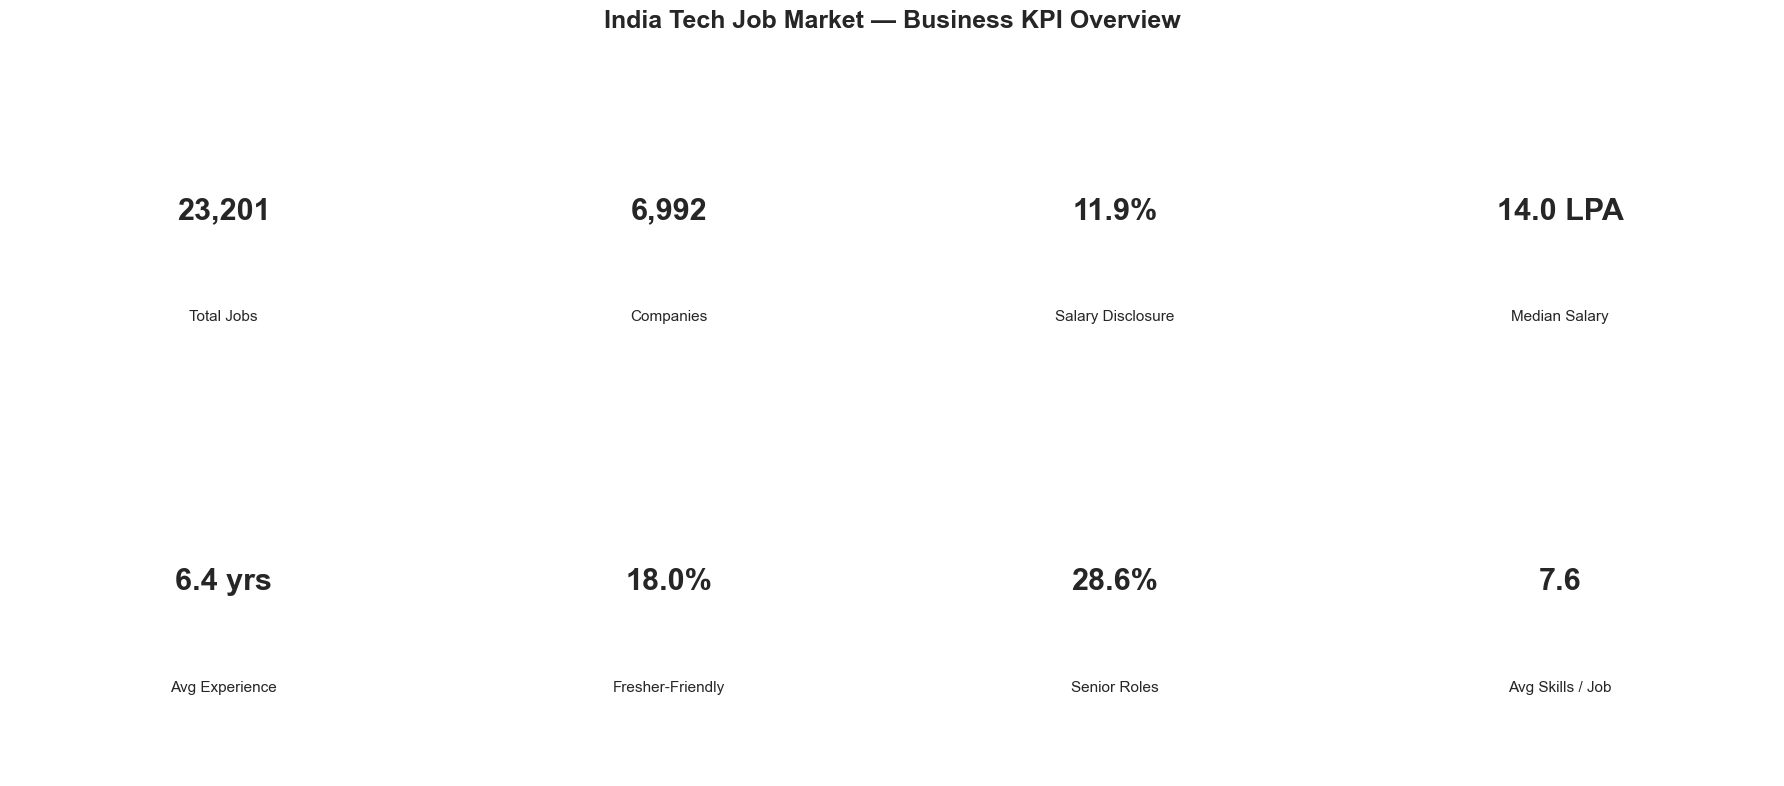

In [13]:
# ============================================================
# KPI VISUAL SUMMARY
# ============================================================

fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 8)
)

kpis = [
    ("Total Jobs", f"{total_jobs:,}"),
    ("Companies", f"{unique_companies:,}"),
    ("Salary Disclosure", f"{salary_disclosure_rate:.1f}%"),
    ("Median Salary", f"{median_salary:.1f} LPA"),
    ("Avg Experience", f"{avg_experience:.1f} yrs"),
    ("Fresher-Friendly", f"{fresher_friendly_rate:.1f}%"),
    ("Senior Roles", f"{senior_role_rate:.1f}%"),
    ("Avg Skills / Job", f"{avg_skills_per_job:.1f}")
]

for ax, (title, value) in zip(
    axes.flatten(),
    kpis
):
    ax.text(
        0.5,
        0.55,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle(
    "India Tech Job Market — Business KPI Overview",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

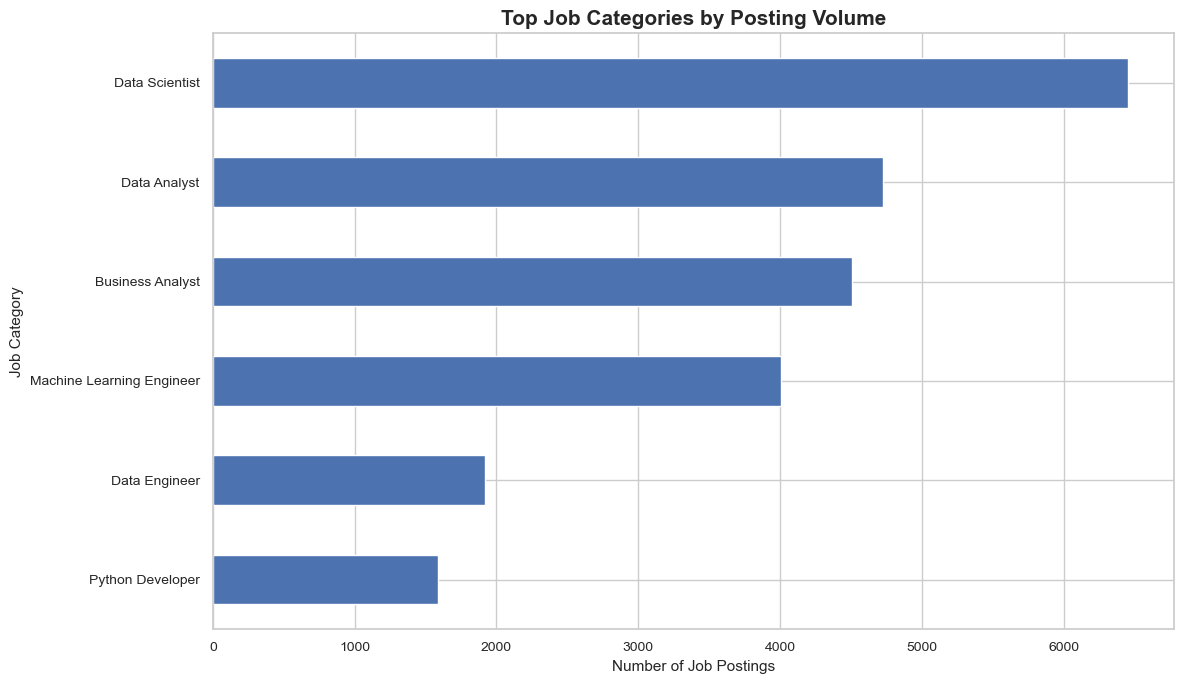

In [15]:
# ============================================================
# JOB DEMAND BY ROLE
# ============================================================

role_demand = (
    df["role_category"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

role_demand.plot(
    kind="barh"
)

plt.title(
    "Top Job Categories by Posting Volume",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

In [17]:
role_share = (
    df["role_category"]
    .value_counts(normalize=True)
    .head(10)
    * 100
)

display(
    role_share.rename(
        "Job Posting Share (%)"
    ).round(2)
)

role_category
Data Scientist               27.82
Data Analyst                 20.38
Business Analyst             19.42
Machine Learning Engineer    17.26
Data Engineer                 8.28
Python Developer              6.84
Name: Job Posting Share (%), dtype: float64

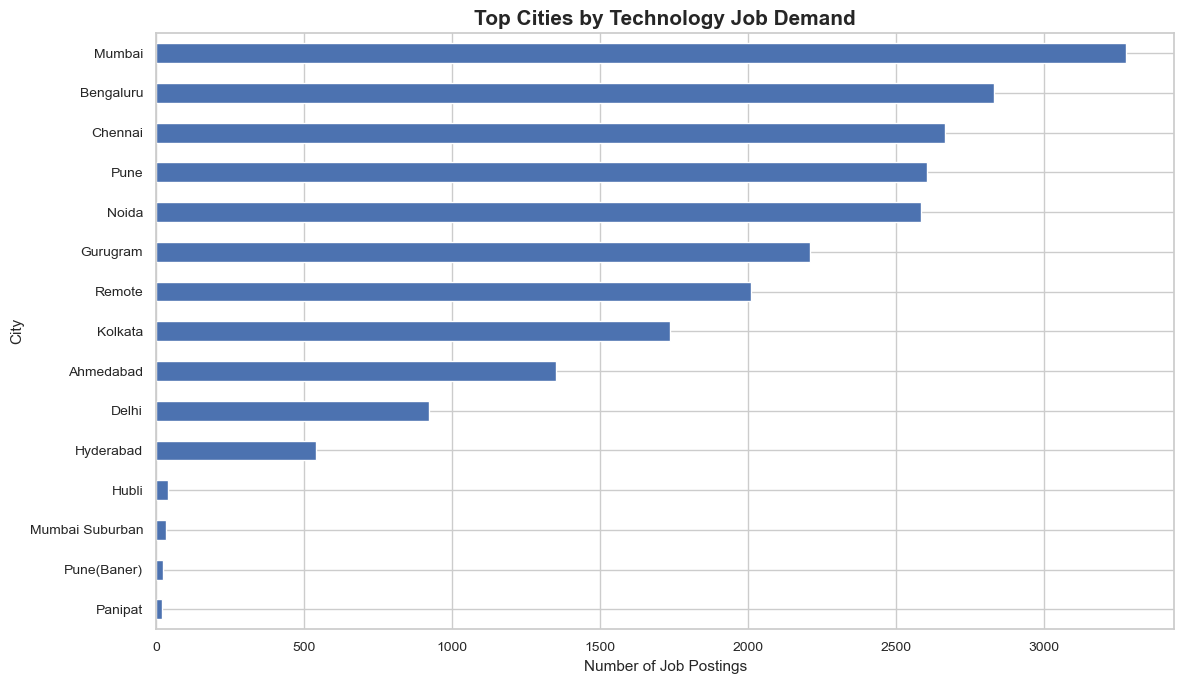

In [19]:
# ============================================================
# JOB DEMAND BY CITY
# ============================================================

city_demand = (
    df["primary_city_clean"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

city_demand.plot(
    kind="barh"
)

plt.title(
    "Top Cities by Technology Job Demand",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("City")

plt.tight_layout()
plt.show()

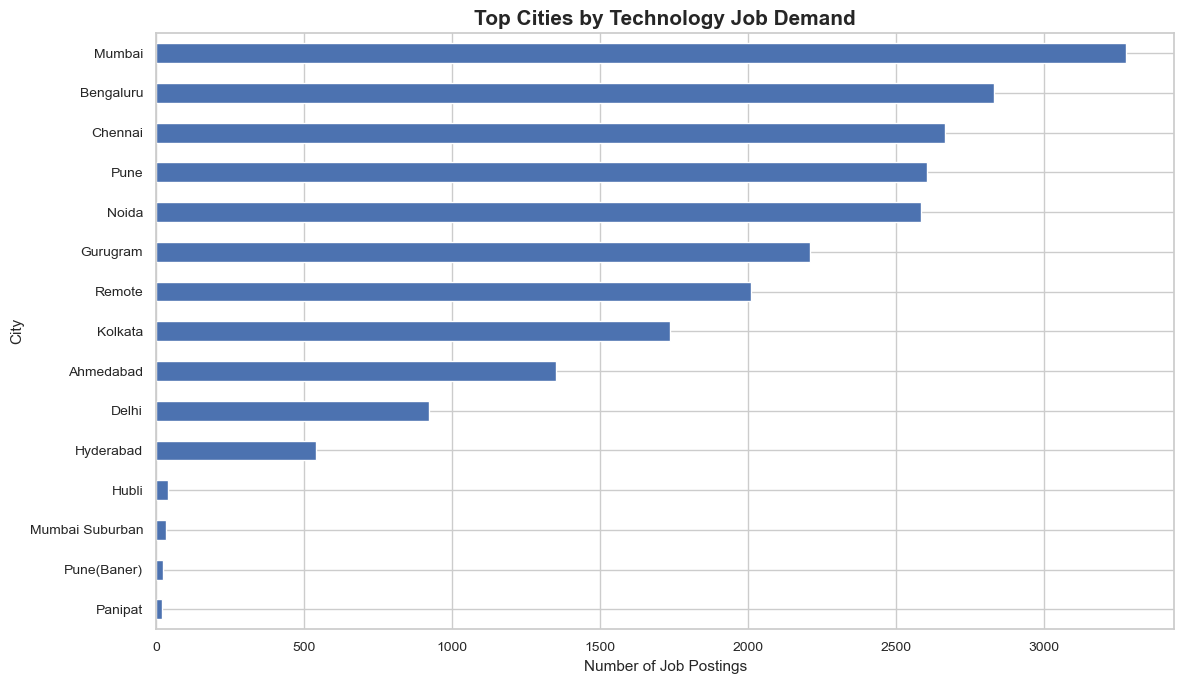

In [21]:
# ============================================================
# JOB DEMAND BY CITY
# ============================================================

city_demand = (
    df["primary_city_clean"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

city_demand.plot(
    kind="barh"
)

plt.title(
    "Top Cities by Technology Job Demand",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("City")

plt.tight_layout()
plt.show()

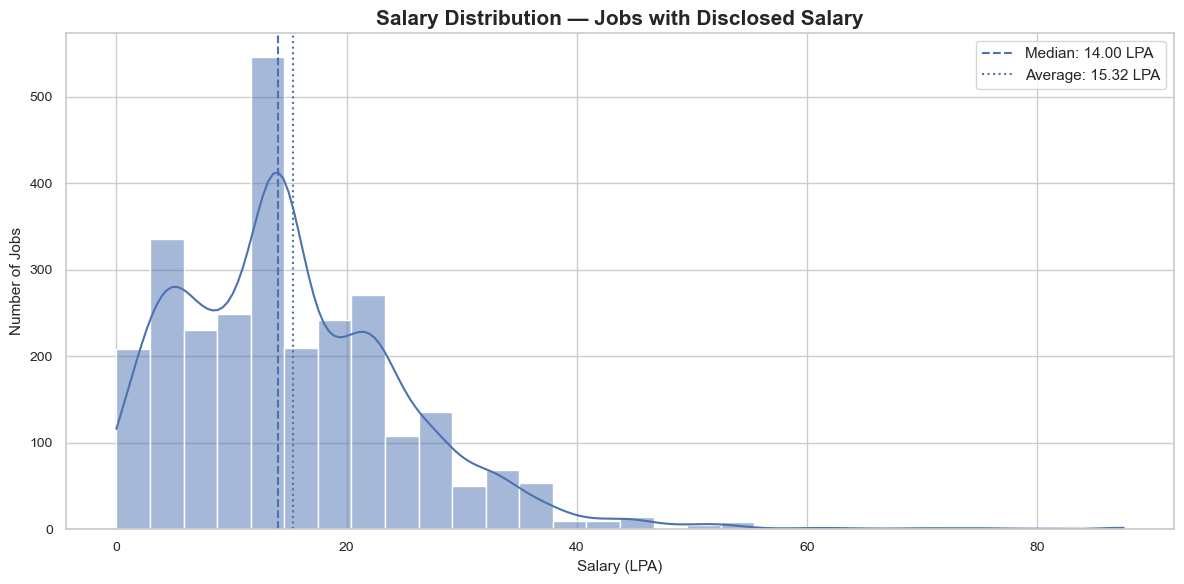

In [23]:
# ============================================================
# SALARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    salary_df["salary_midpoint_clean"],
    bins=30,
    kde=True
)

plt.axvline(
    median_salary,
    linestyle="--",
    label=f"Median: {median_salary:.2f} LPA"
)

plt.axvline(
    avg_salary,
    linestyle=":",
    label=f"Average: {avg_salary:.2f} LPA"
)

plt.title(
    "Salary Distribution — Jobs with Disclosed Salary",
    fontweight="bold"
)

plt.xlabel("Salary (LPA)")
plt.ylabel("Number of Jobs")

plt.legend()

plt.tight_layout()
plt.show()

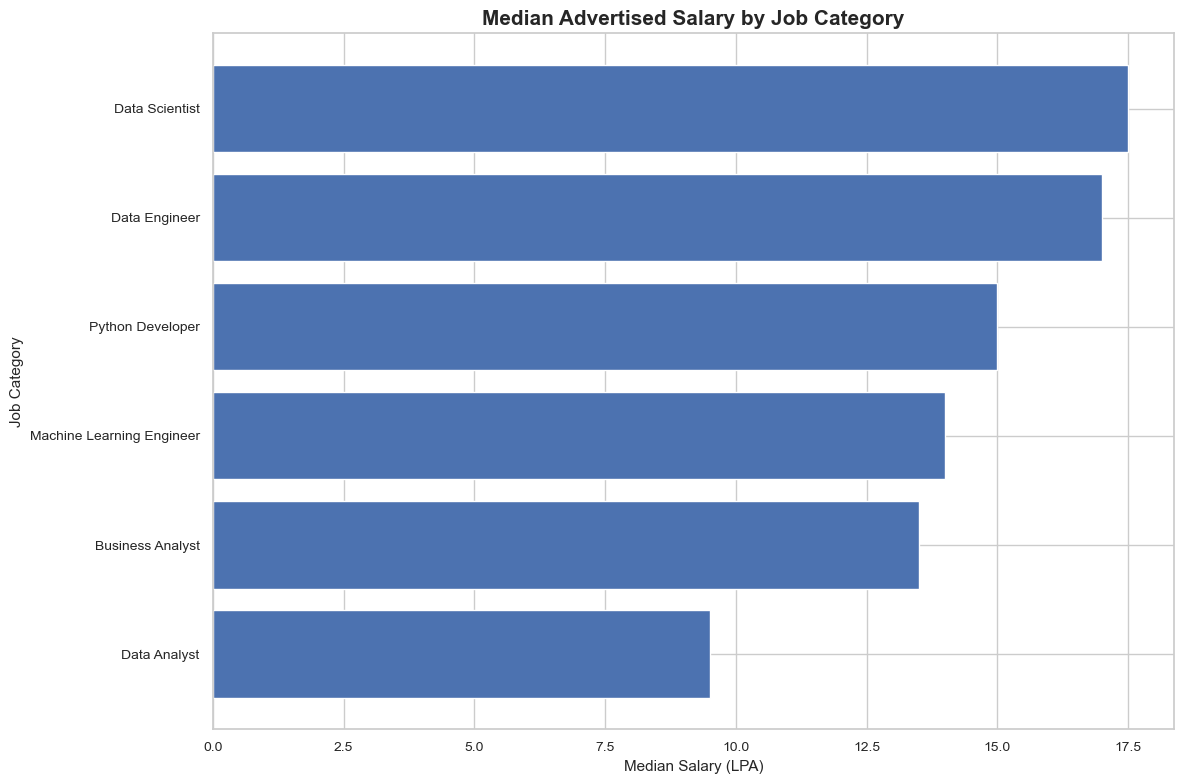

In [25]:
# ============================================================
# SALARY BY ROLE
# ============================================================

salary_by_role = (
    salary_df
    .groupby("role_category")
    .agg(
        jobs=("job_id", "count"),
        average_salary=("salary_midpoint_clean", "mean"),
        median_salary=("salary_midpoint_clean", "median")
    )
    .query("jobs >= 20")
    .sort_values(
        "median_salary",
        ascending=False
    )
)

top_salary_roles = (
    salary_by_role
    .head(15)
    .sort_values("median_salary")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_salary_roles.index,
    top_salary_roles["median_salary"]
)

plt.title(
    "Median Advertised Salary by Job Category",
    fontweight="bold"
)

plt.xlabel("Median Salary (LPA)")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

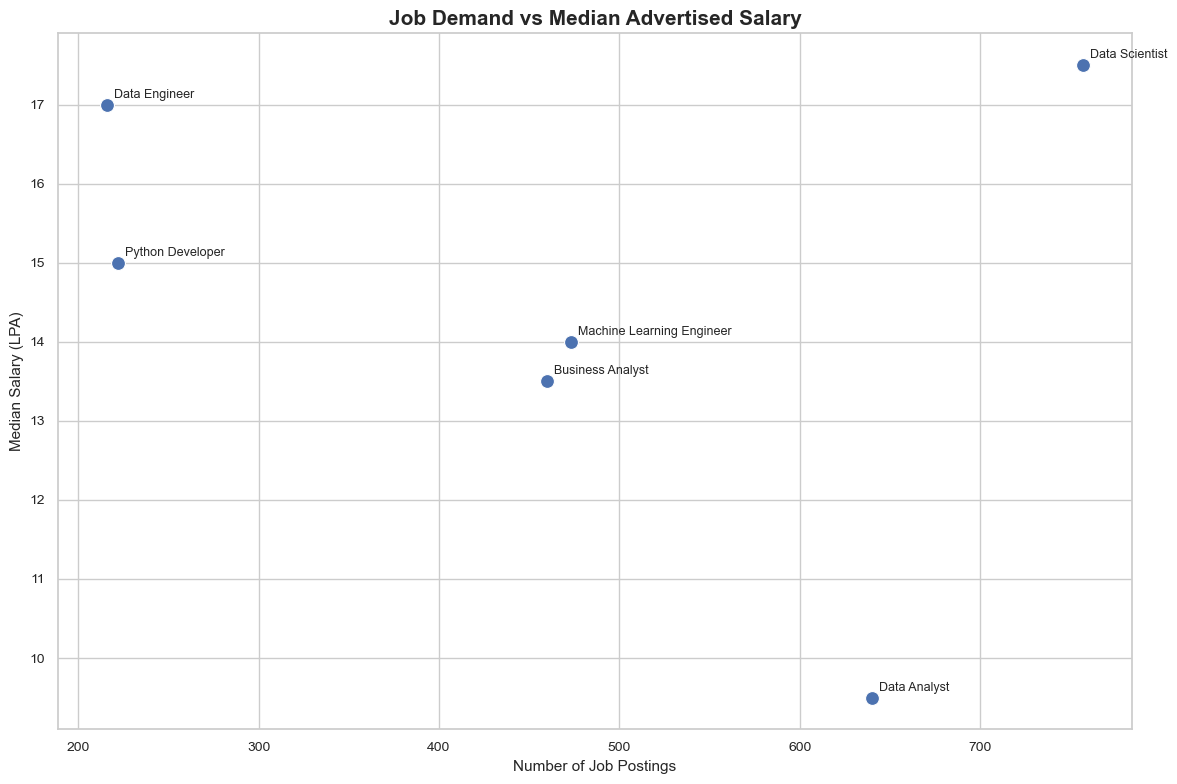

In [27]:
# ============================================================
# DEMAND VS SALARY
# ============================================================

role_business = (
    salary_df
    .groupby("role_category")
    .agg(
        job_postings=("job_id", "count"),
        median_salary=("salary_midpoint_clean", "median")
    )
    .reset_index()
)

role_business = role_business[
    role_business["job_postings"] >= 20
]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=role_business,
    x="job_postings",
    y="median_salary",
    s=100
)

for _, row in role_business.iterrows():

    plt.annotate(
        row["role_category"],
        (
            row["job_postings"],
            row["median_salary"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Job Demand vs Median Advertised Salary",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Median Salary (LPA)")

plt.tight_layout()
plt.show()

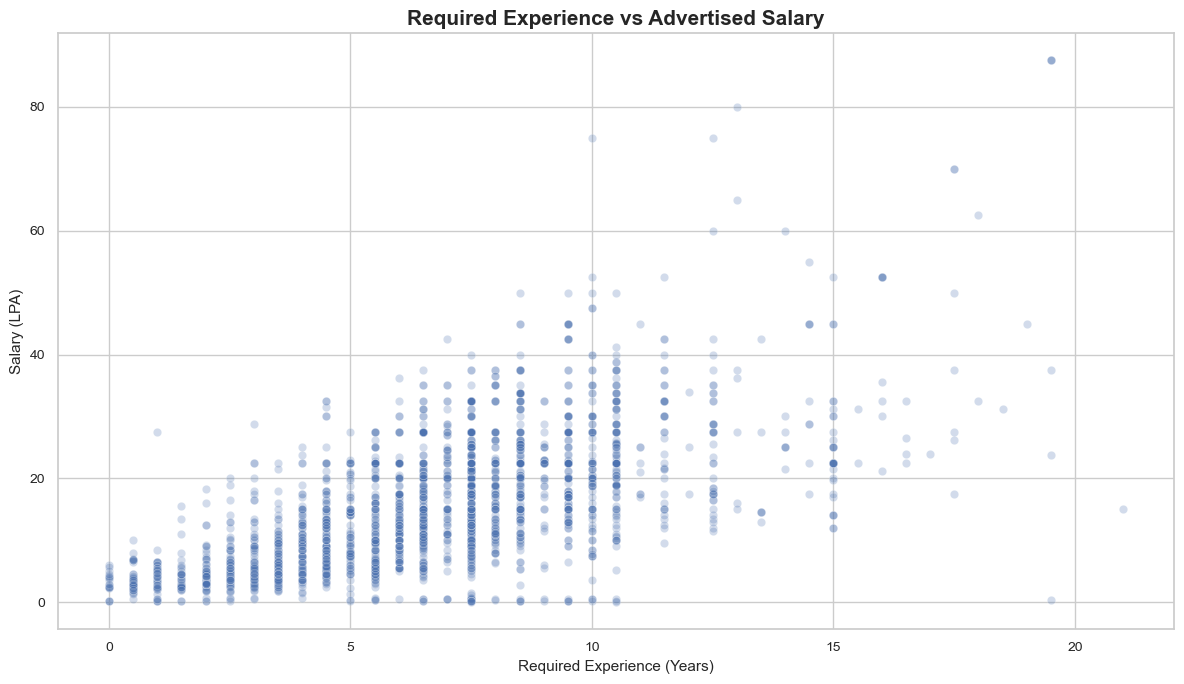

In [29]:
# ============================================================
# EXPERIENCE VS SALARY
# ============================================================

experience_salary = salary_df[
    salary_df["experience_midpoint_clean"].notna()
].copy()

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=experience_salary,
    x="experience_midpoint_clean",
    y="salary_midpoint_clean",
    alpha=0.25
)

plt.title(
    "Required Experience vs Advertised Salary",
    fontweight="bold"
)

plt.xlabel("Required Experience (Years)")
plt.ylabel("Salary (LPA)")

plt.tight_layout()
plt.show()

,jobs,median_salary,average_salary
experience_tier_clean,,,
Fresher,182,3.500,4.321813
Junior (0-2 Yrs),348,5.325,6.928506
Mid (3-5 Yrs),999,14.000,14.904454
Not Available,373,14.000,12.162788
Senior (6-8 Yrs),682,20.500,21.062947
Lead/Architect (9+ Yrs),184,27.500,29.454076


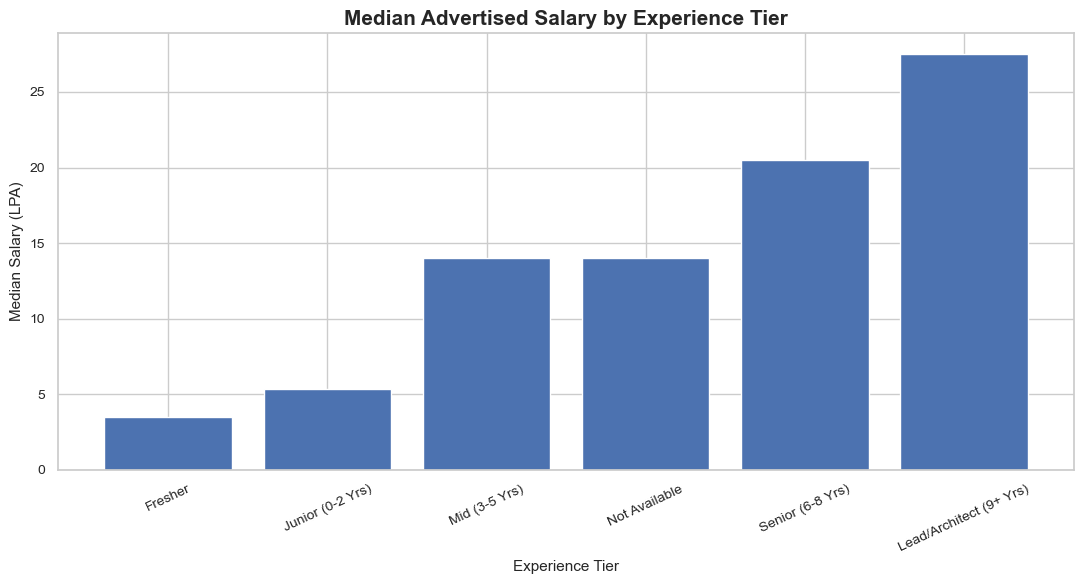

In [31]:
# ============================================================
# SALARY BY EXPERIENCE TIER
# ============================================================

experience_salary_summary = (
    salary_df
    .groupby("experience_tier_clean")
    .agg(
        jobs=("job_id", "count"),
        median_salary=("salary_midpoint_clean", "median"),
        average_salary=("salary_midpoint_clean", "mean")
    )
    .sort_values(
        "median_salary"
    )
)

display(
    experience_salary_summary
)

plt.figure(figsize=(11, 6))

plt.bar(
    experience_salary_summary.index,
    experience_salary_summary["median_salary"]
)

plt.title(
    "Median Advertised Salary by Experience Tier",
    fontweight="bold"
)

plt.xlabel("Experience Tier")
plt.ylabel("Median Salary (LPA)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

,Job_Postings,Percentage
is_fresher_friendly,,
Not Fresher Friendly,19019,81.97
Fresher Friendly,4182,18.03


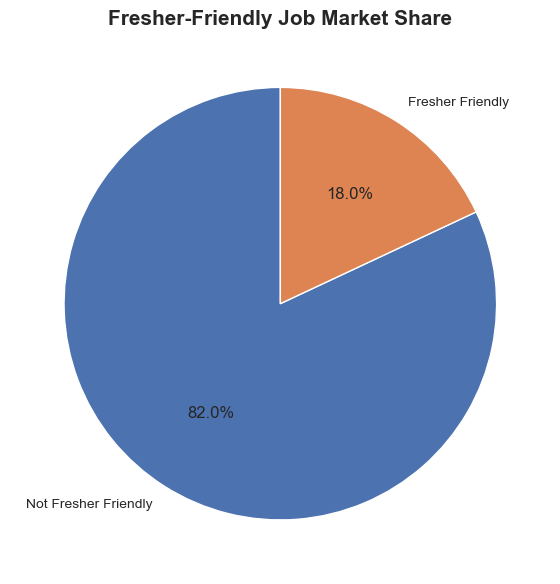

In [33]:
# ============================================================
# FRESHER OPPORTUNITY
# ============================================================

fresher_counts = (
    df["is_fresher_friendly"]
    .value_counts()
    .rename(
        index={
            True: "Fresher Friendly",
            False: "Not Fresher Friendly"
        }
    )
)

fresher_pct = (
    fresher_counts /
    fresher_counts.sum()
    * 100
)

fresher_summary = pd.DataFrame({
    "Job_Postings": fresher_counts,
    "Percentage": fresher_pct.round(2)
})

display(fresher_summary)

plt.figure(figsize=(8, 6))

plt.pie(
    fresher_counts,
    labels=fresher_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Fresher-Friendly Job Market Share",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

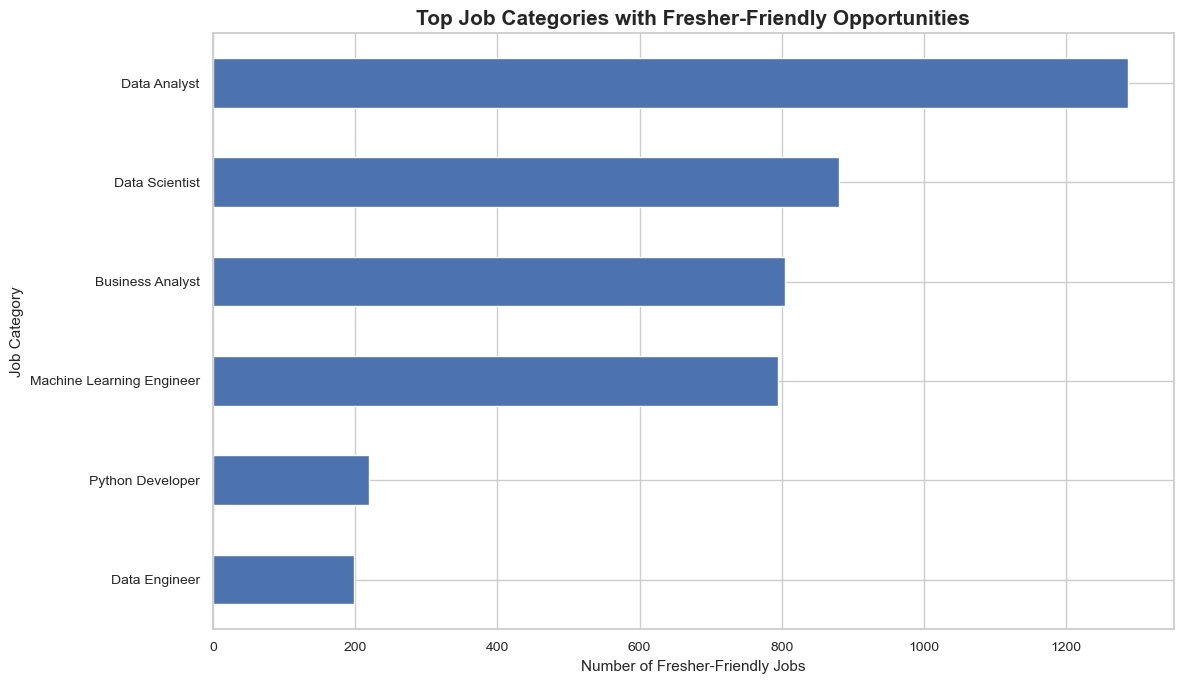

In [35]:
# ============================================================
# FRESHER OPPORTUNITIES BY ROLE
# ============================================================

fresher_role = (
    df[df["is_fresher_friendly"] == True]
    ["role_category"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

fresher_role.plot(
    kind="barh"
)

plt.title(
    "Top Job Categories with Fresher-Friendly Opportunities",
    fontweight="bold"
)

plt.xlabel("Number of Fresher-Friendly Jobs")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

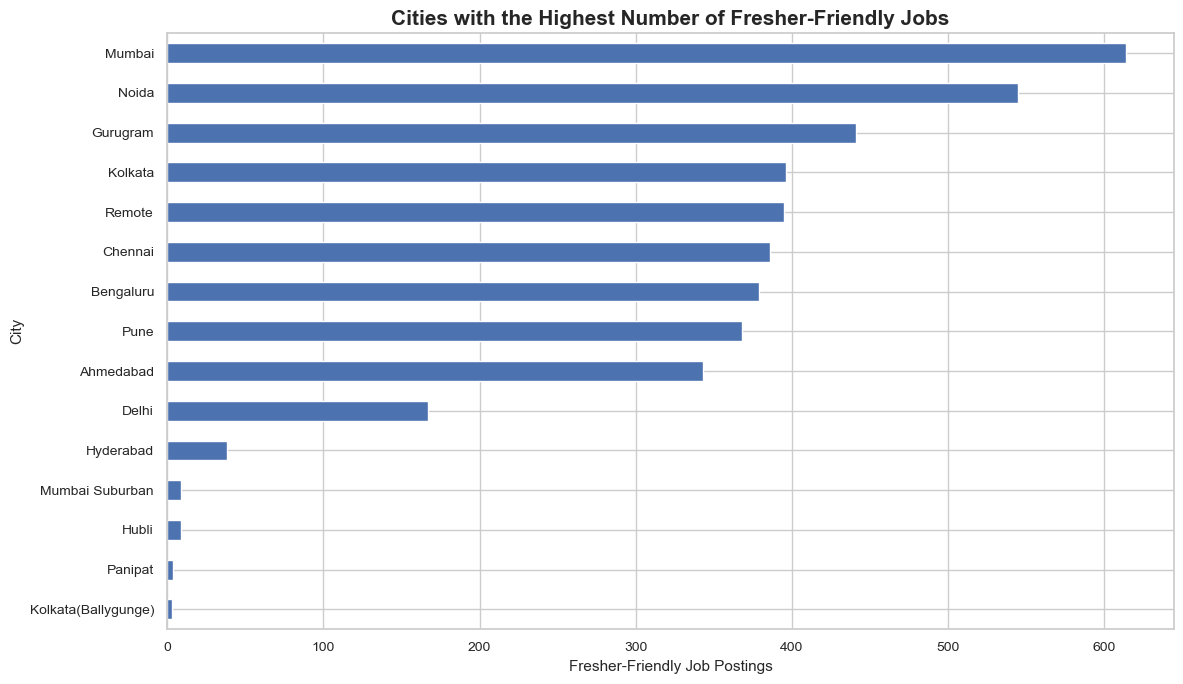

In [39]:
# ============================================================
# FRESHER JOBS BY CITY
# ============================================================

fresher_city = (
    df[df["is_fresher_friendly"] == True]
    ["primary_city_clean"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

fresher_city.plot(
    kind="barh"
)

plt.title(
    "Cities with the Highest Number of Fresher-Friendly Jobs",
    fontweight="bold"
)

plt.xlabel("Fresher-Friendly Job Postings")
plt.ylabel("City")

plt.tight_layout()
plt.show()

,Job_Postings,Percentage
work_mode_clean,,
On-site,18701,80.60
Hybrid,2347,10.12
Remote,2153,9.28


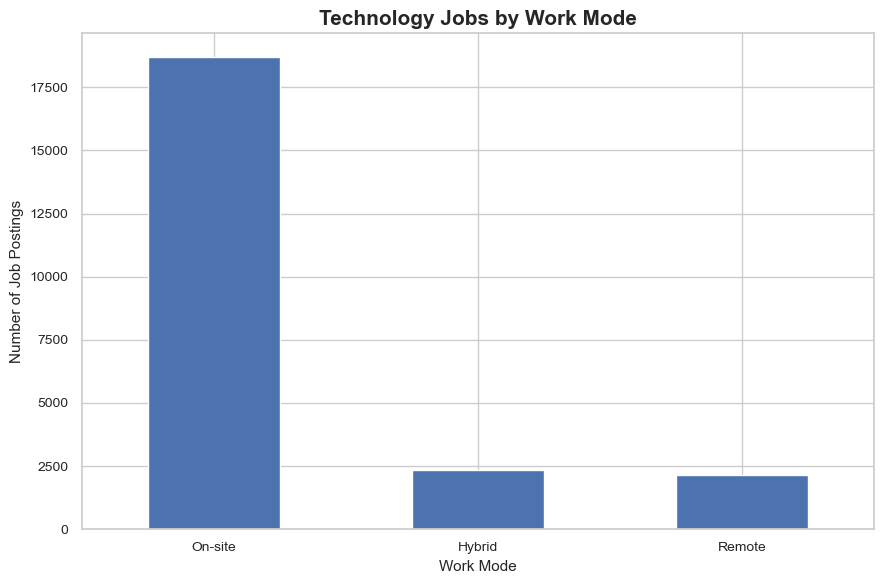

In [41]:
# ============================================================
# WORK MODE
# ============================================================

work_mode = (
    df["work_mode_clean"]
    .value_counts()
)

work_mode_pct = (
    work_mode /
    work_mode.sum()
    * 100
)

work_mode_table = pd.DataFrame({
    "Job_Postings": work_mode,
    "Percentage": work_mode_pct.round(2)
})

display(work_mode_table)

plt.figure(figsize=(9, 6))

work_mode.plot(
    kind="bar"
)

plt.title(
    "Technology Jobs by Work Mode",
    fontweight="bold"
)

plt.xlabel("Work Mode")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

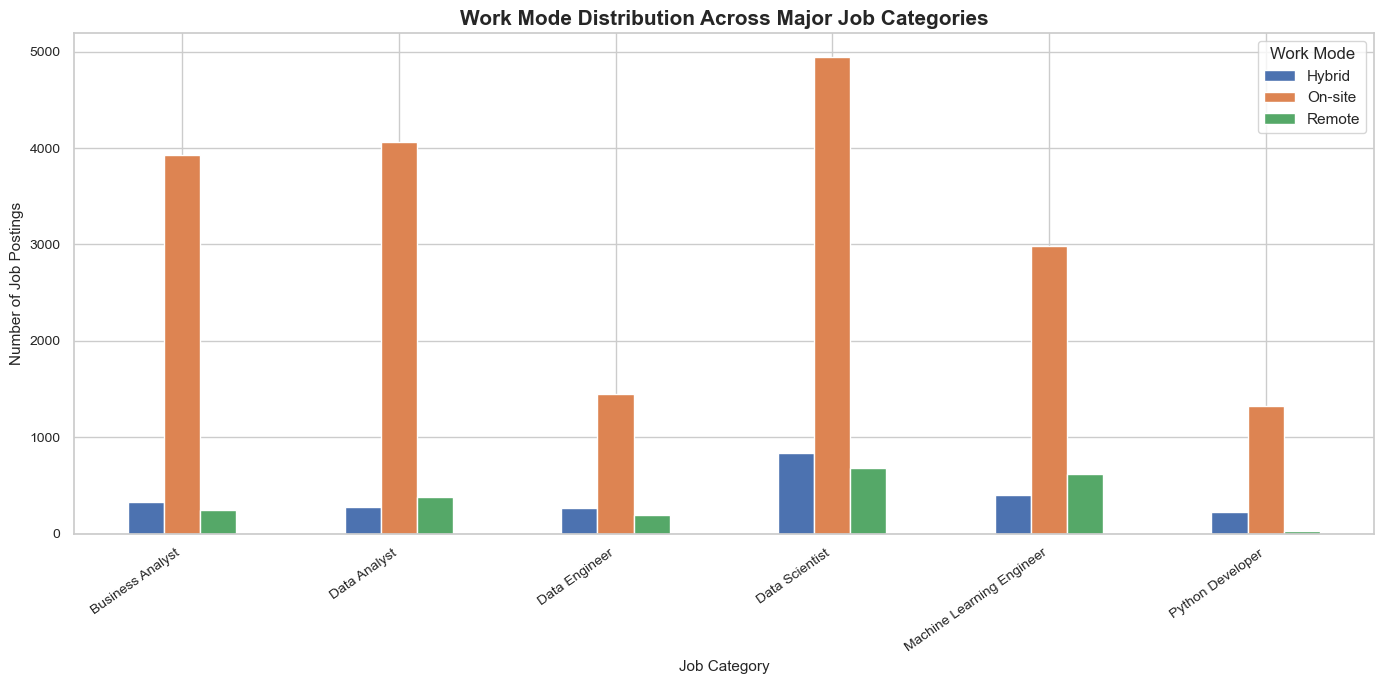

In [43]:
# ============================================================
# WORK MODE BY ROLE
# ============================================================

work_role = pd.crosstab(
    df["role_category"],
    df["work_mode_clean"]
)

top_roles = (
    df["role_category"]
    .value_counts()
    .head(10)
    .index
)

work_role_top = work_role.loc[
    work_role.index.intersection(top_roles)
]

work_role_top.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Work Mode Distribution Across Major Job Categories",
    fontweight="bold"
)

plt.xlabel("Job Category")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=35, ha="right")

plt.legend(
    title="Work Mode"
)

plt.tight_layout()
plt.show()

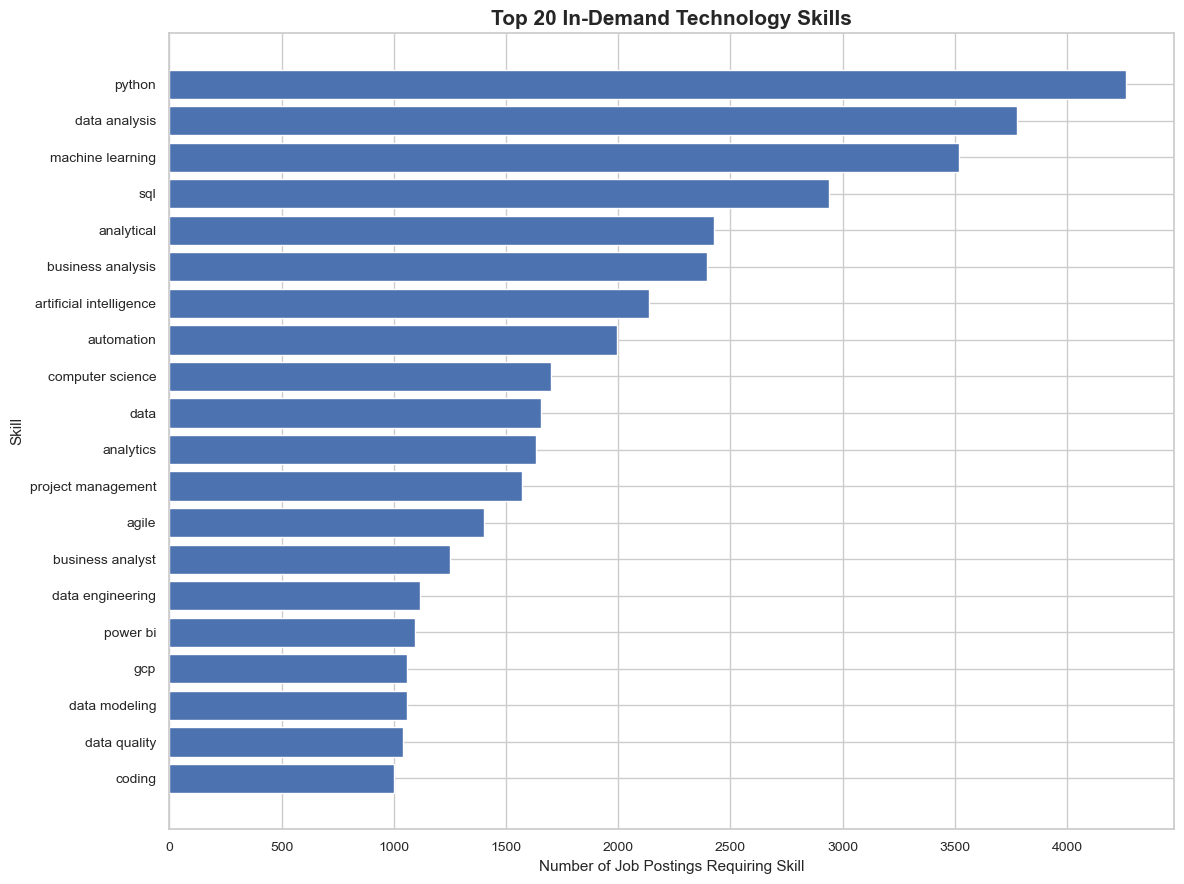

In [45]:
# ============================================================
# TOP SKILLS
# ============================================================

top_skills = (
    skill_demand
    .head(20)
    .sort_values("job_count")
)

plt.figure(figsize=(12, 9))

plt.barh(
    top_skills["skill"],
    top_skills["job_count"]
)

plt.title(
    "Top 20 In-Demand Technology Skills",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings Requiring Skill")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# SKILL DEMAND SHARE
# ============================================================

total_skill_jobs = (
    df["job_id"].nunique()
)

skill_demand["demand_share_pct"] = (
    skill_demand["job_count"]
    /
    total_skill_jobs
    * 100
)

top_skill_business = (
    skill_demand
    .head(20)
    .copy()
)

display(
    top_skill_business
)

,skill,job_count,demand_share_pct
7680,python,4264,18.378518
2561,data analysis,3776,16.275161
5775,machine learning,3520,15.171760
9253,sql,2940,12.671868
477,analytical,2427,10.460756
1331,business analysis,2396,10.327141
703,artificial intelligence,2137,9.210810
817,automation,1995,8.598767
2083,computer science,1699,7.322960
2555,data,1654,7.129003


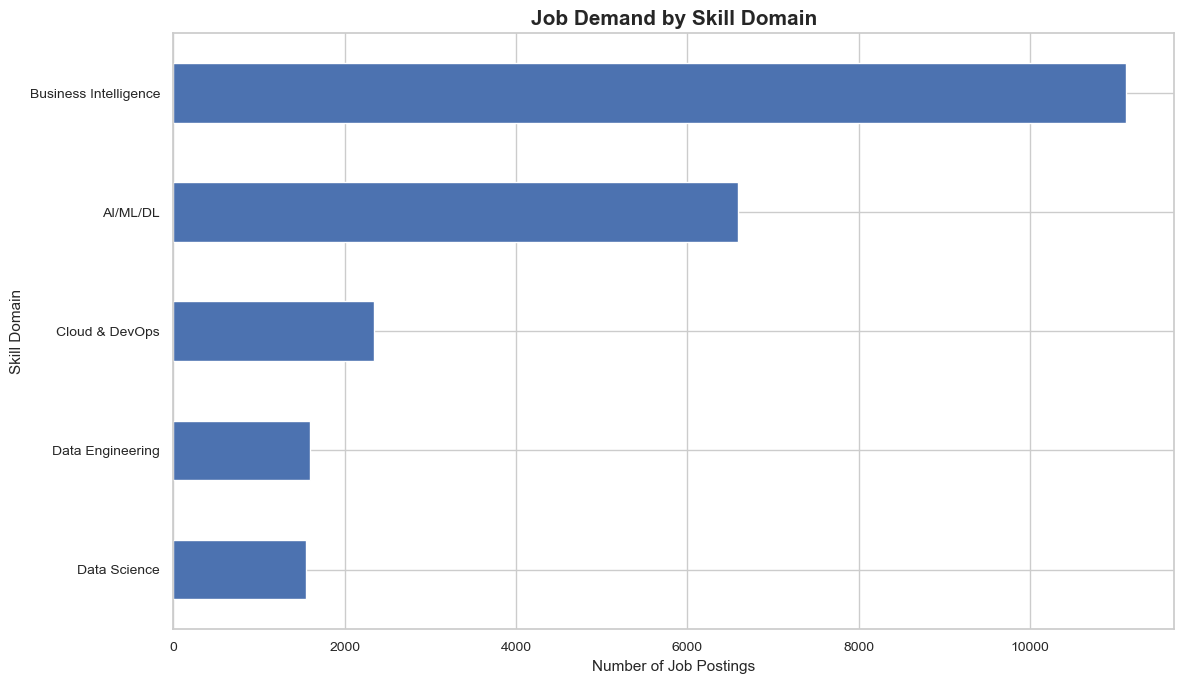

In [49]:
# ============================================================
# SKILL DOMAIN DEMAND
# ============================================================

domain_demand = (
    df["skill_domain"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

domain_demand.plot(
    kind="barh"
)

plt.title(
    "Job Demand by Skill Domain",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Skill Domain")

plt.tight_layout()
plt.show()

,jobs,avg_skills
role_category,,
Data Engineer,1922,7.701873
Data Scientist,6455,7.643842
Machine Learning Engineer,4004,7.590160
Business Analyst,4505,7.578912
Data Analyst,4729,7.573271
Python Developer,1586,7.504414


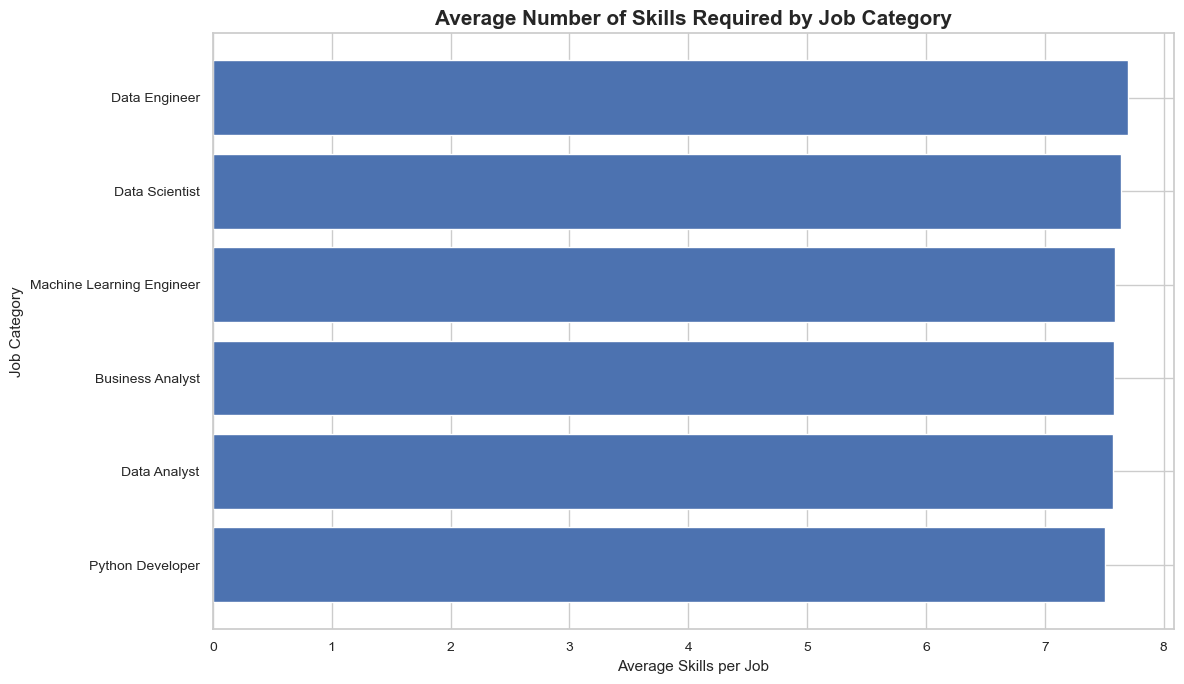

In [51]:
# ============================================================
# SKILLS PER JOB
# ============================================================

skills_by_role = (
    df
    .groupby("role_category")
    .agg(
        jobs=("job_id", "count"),
        avg_skills=("skills_count_clean", "mean")
    )
    .query("jobs >= 20")
    .sort_values(
        "avg_skills",
        ascending=False
    )
)

display(
    skills_by_role.head(15)
)

top_skill_intensive_roles = (
    skills_by_role
    .head(15)
    .sort_values("avg_skills")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_skill_intensive_roles.index,
    top_skill_intensive_roles["avg_skills"]
)

plt.title(
    "Average Number of Skills Required by Job Category",
    fontweight="bold"
)

plt.xlabel("Average Skills per Job")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

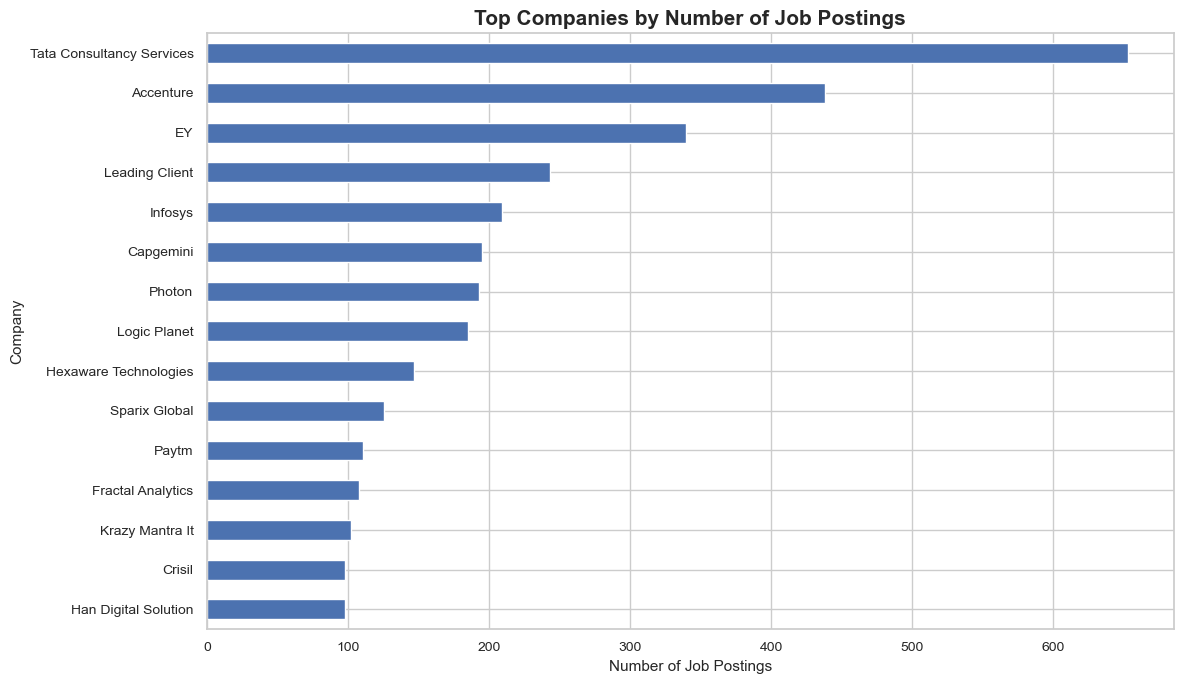

In [53]:
# ============================================================
# TOP COMPANIES
# ============================================================

company_demand = (
    df["company_name"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

company_demand.plot(
    kind="barh"
)

plt.title(
    "Top Companies by Number of Job Postings",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

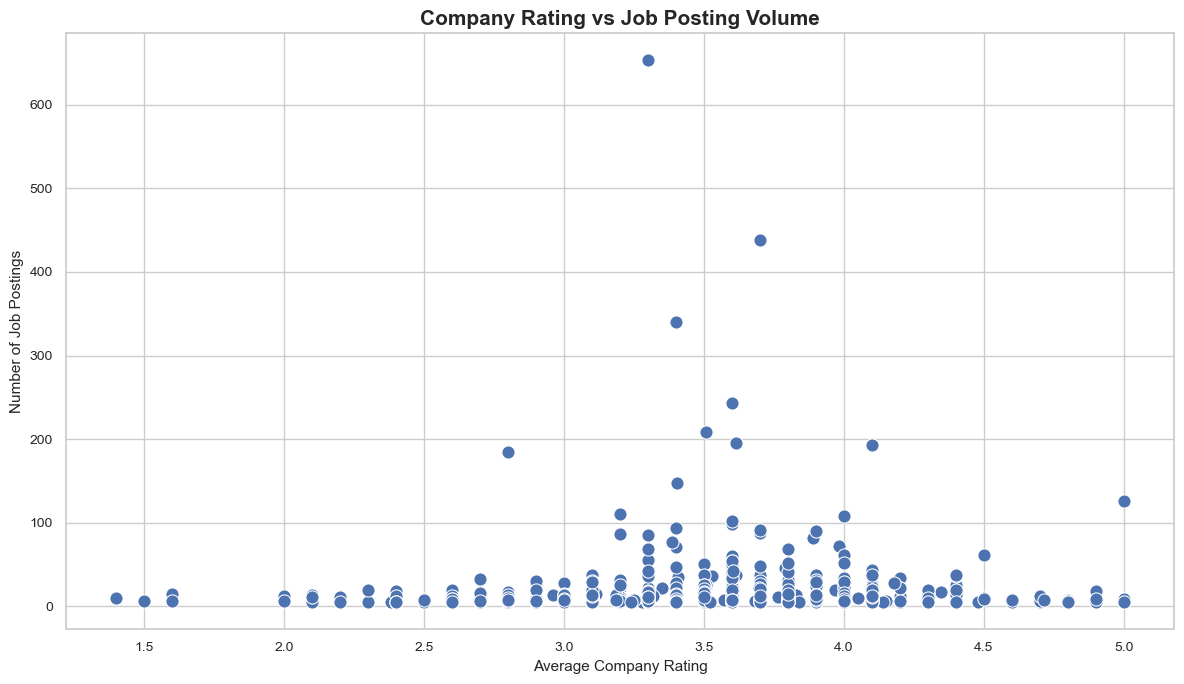

In [55]:
# ============================================================
# COMPANY RATING VS JOB POSTINGS
# ============================================================

company_analysis = (
    df
    .dropna(subset=["company_name"])
    .groupby("company_name")
    .agg(
        job_postings=("job_id", "count"),
        average_rating=("company_rating", "mean")
    )
    .reset_index()
)

company_analysis = company_analysis[
    company_analysis["job_postings"] >= 5
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=company_analysis,
    x="average_rating",
    y="job_postings",
    s=90
)

plt.title(
    "Company Rating vs Job Posting Volume",
    fontweight="bold"
)

plt.xlabel("Average Company Rating")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

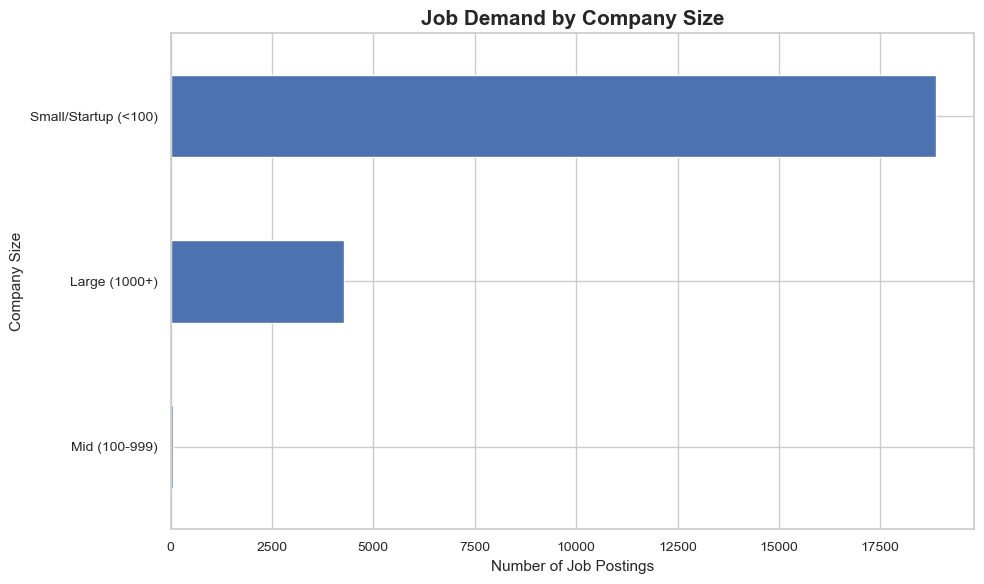

In [57]:
# ============================================================
# COMPANY SIZE
# ============================================================

company_size = (
    df["company_size_bucket"]
    .dropna()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

company_size.plot(
    kind="barh"
)

plt.title(
    "Job Demand by Company Size",
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Company Size")

plt.tight_layout()
plt.show()

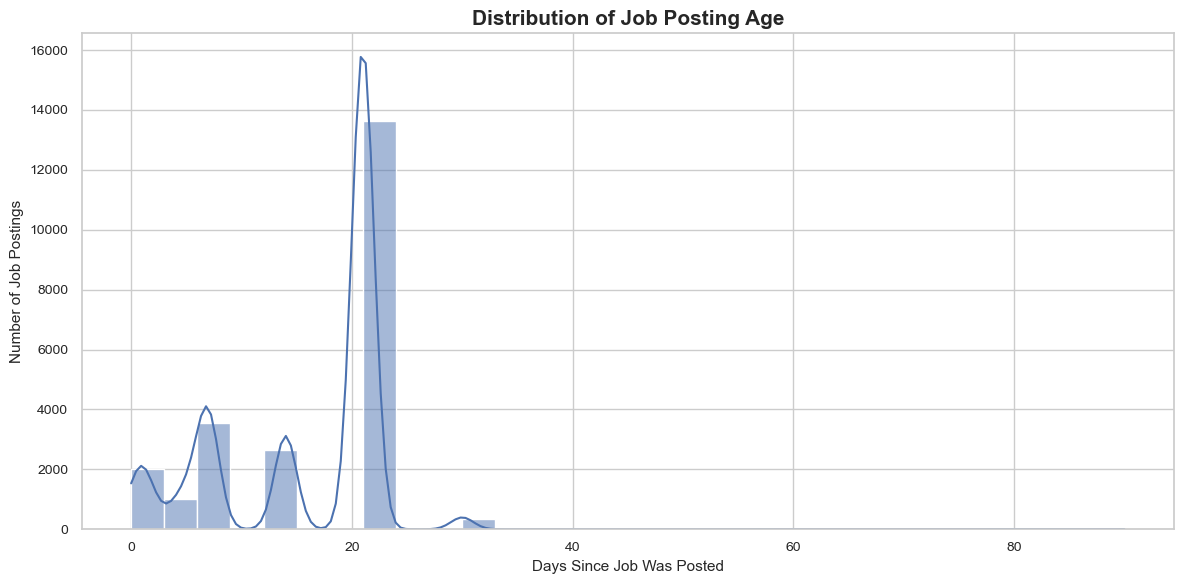

In [59]:
# ============================================================
# JOB POSTING RECENCY
# ============================================================

recency = df[
    df["days_since_posted"].notna()
].copy()

plt.figure(figsize=(12, 6))

sns.histplot(
    recency["days_since_posted"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Job Posting Age",
    fontweight="bold"
)

plt.xlabel("Days Since Job Was Posted")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

,total_jobs,salary_disclosed,disclosure_rate
role_category,,,
Python Developer,1586,222,13.997478
Data Analyst,4729,640,13.533517
Machine Learning Engineer,4004,473,11.813187
Data Scientist,6455,757,11.727343
Data Engineer,1922,216,11.238293
Business Analyst,4505,460,10.210877


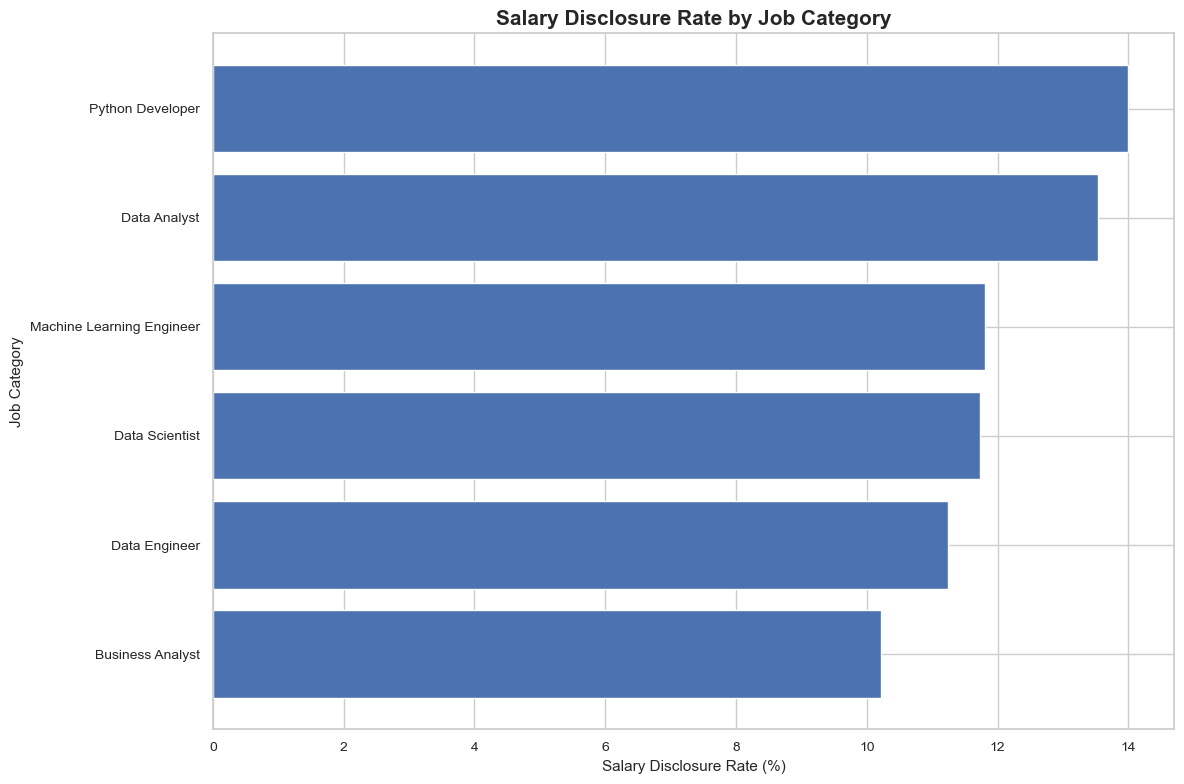

In [61]:
# ============================================================
# SALARY DISCLOSURE BY ROLE
# ============================================================

salary_disclosure_role = (
    df
    .groupby("role_category")
    .agg(
        total_jobs=("job_id", "count"),
        salary_disclosed=("salary_disclosed", "sum")
    )
)

salary_disclosure_role["disclosure_rate"] = (
    salary_disclosure_role["salary_disclosed"]
    /
    salary_disclosure_role["total_jobs"]
    * 100
)

salary_disclosure_role = (
    salary_disclosure_role
    .query("total_jobs >= 20")
    .sort_values(
        "disclosure_rate",
        ascending=False
    )
)

display(
    salary_disclosure_role.head(15)
)

plt.figure(figsize=(12, 8))

top_disclosure = (
    salary_disclosure_role
    .head(15)
    .sort_values("disclosure_rate")
)

plt.barh(
    top_disclosure.index,
    top_disclosure["disclosure_rate"]
)

plt.title(
    "Salary Disclosure Rate by Job Category",
    fontweight="bold"
)

plt.xlabel("Salary Disclosure Rate (%)")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

,jobs,median_salary,average_salary
primary_city_clean,,,
Hyderabad,145,20.000,19.857759
Pune,322,18.250,19.038929
Bengaluru,261,15.000,15.752586
Chennai,371,15.000,17.022089
Delhi,112,14.000,15.904911
Gurugram,217,14.000,14.854585
Kolkata,154,14.000,12.727240
Mumbai,353,14.000,16.066218
Remote,153,14.000,14.556993


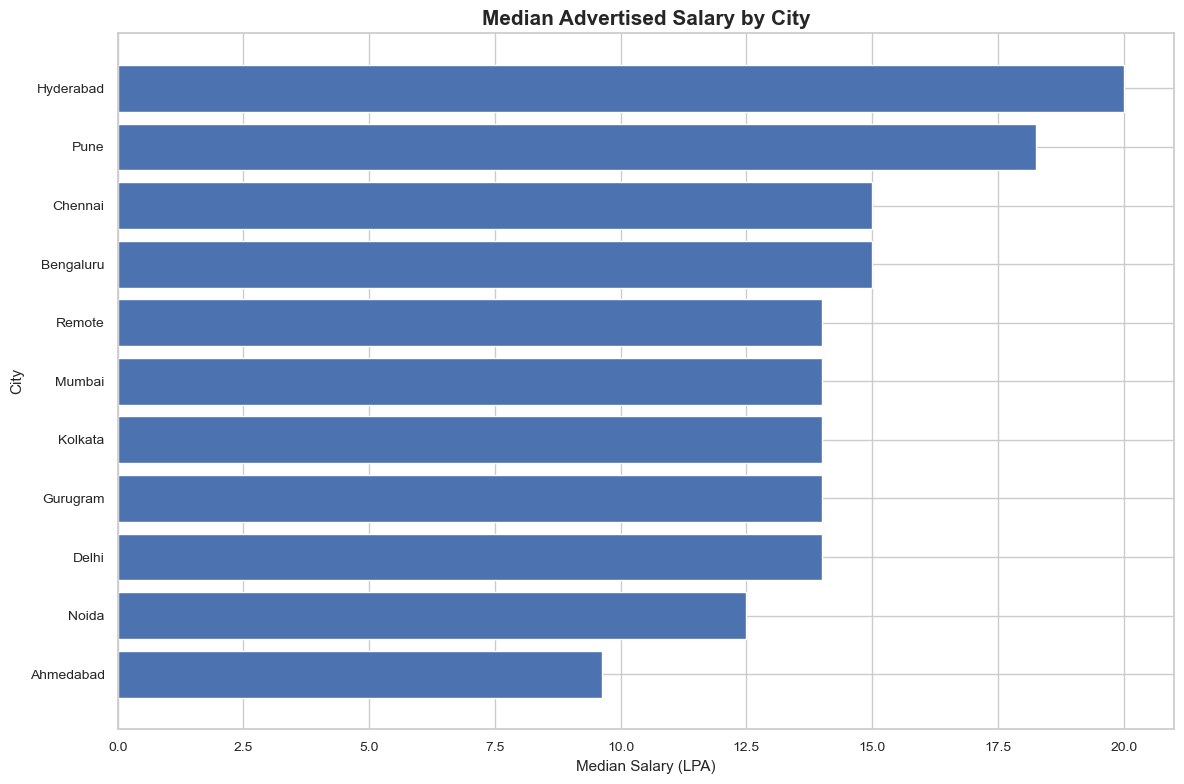

In [63]:
# ============================================================
# CITY VS SALARY
# ============================================================

city_salary = (
    salary_df
    .groupby("primary_city_clean")
    .agg(
        jobs=("job_id", "count"),
        median_salary=("salary_midpoint_clean", "median"),
        average_salary=("salary_midpoint_clean", "mean")
    )
    .query("jobs >= 30")
    .sort_values(
        "median_salary",
        ascending=False
    )
)

display(
    city_salary.head(15)
)

top_city_salary = (
    city_salary
    .head(15)
    .sort_values("median_salary")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_city_salary.index,
    top_city_salary["median_salary"]
)

plt.title(
    "Median Advertised Salary by City",
    fontweight="bold"
)

plt.xlabel("Median Salary (LPA)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

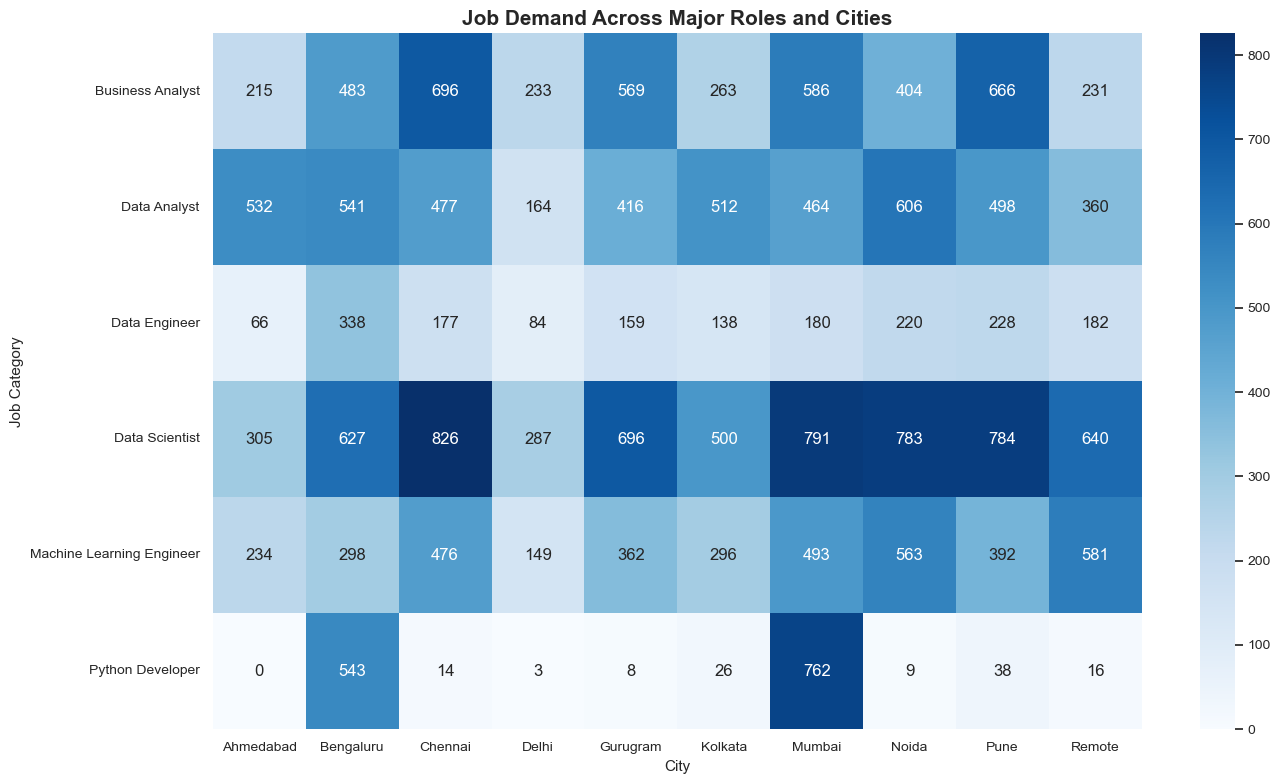

In [65]:
# ============================================================
# ROLE × CITY HEATMAP
# ============================================================

top_role_names = (
    df["role_category"]
    .value_counts()
    .head(10)
    .index
)

top_city_names = (
    df["primary_city_clean"]
    .value_counts()
    .head(10)
    .index
)

role_city = pd.crosstab(
    df["role_category"],
    df["primary_city_clean"]
)

role_city = role_city.loc[
    role_city.index.intersection(top_role_names),
    role_city.columns.intersection(top_city_names)
]

plt.figure(figsize=(14, 8))

sns.heatmap(
    role_city,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Job Demand Across Major Roles and Cities",
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

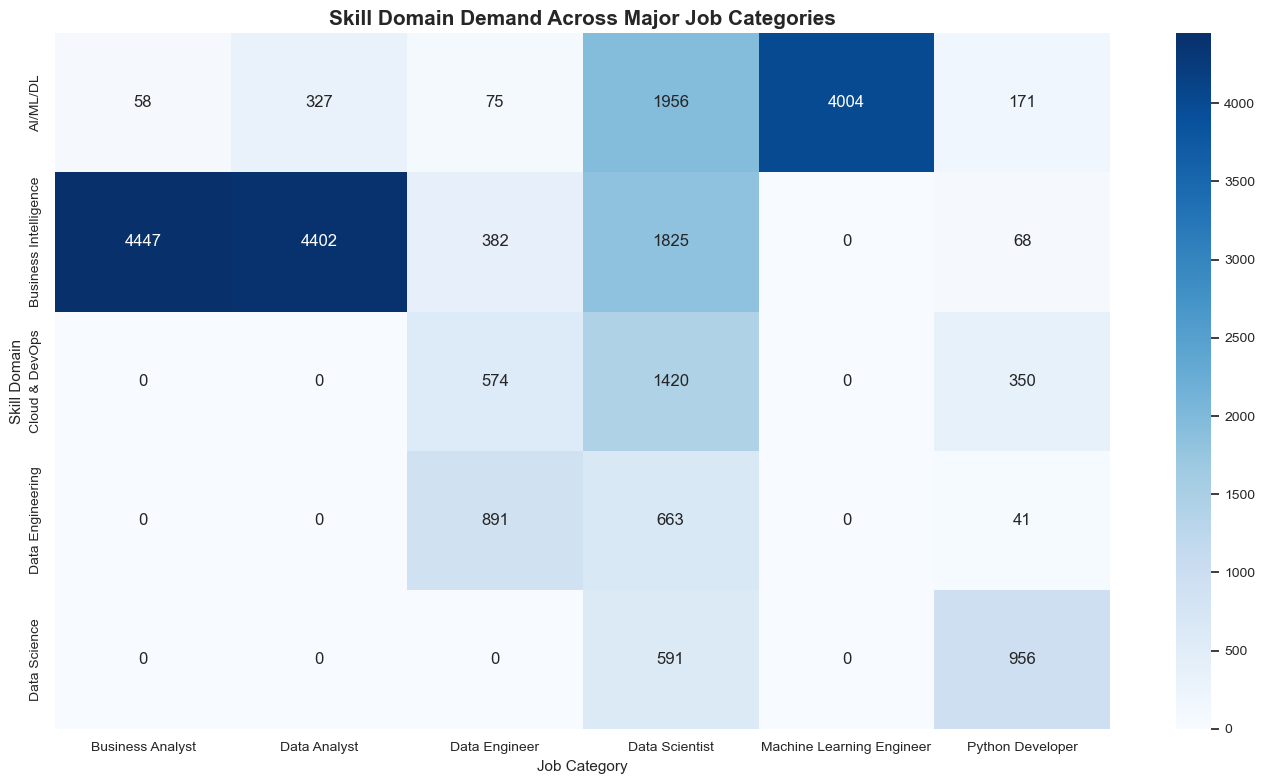

In [67]:
# ============================================================
# SKILL DOMAIN × JOB CATEGORY
# ============================================================

top_roles = (
    df["role_category"]
    .value_counts()
    .head(10)
    .index
)

domain_role = pd.crosstab(
    df["skill_domain"],
    df["role_category"]
)

domain_role = domain_role.loc[
    :,
    domain_role.columns.intersection(top_roles)
]

domain_role = domain_role.head(15)

plt.figure(figsize=(14, 8))

sns.heatmap(
    domain_role,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Skill Domain Demand Across Major Job Categories",
    fontweight="bold"
)

plt.xlabel("Job Category")
plt.ylabel("Skill Domain")

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# ROLE BUSINESS PERFORMANCE TABLE
# ============================================================

role_metrics = (
    df
    .groupby("role_category")
    .agg(
        job_postings=("job_id", "count"),
        companies=("company_name", "nunique"),
        cities=("primary_city_clean", "nunique"),
        salary_disclosure_rate=(
            "salary_disclosed",
            "mean"
        ),
        fresher_friendly_rate=(
            "is_fresher_friendly",
            "mean"
        ),
        senior_role_rate=(
            "is_senior_clean",
            "mean"
        ),
        avg_skills=(
            "skills_count_clean",
            "mean"
        ),
        avg_rating=(
            "company_rating",
            "mean"
        )
    )
    .reset_index()
)

# Convert rates to percentages
role_metrics["salary_disclosure_rate"] *= 100
role_metrics["fresher_friendly_rate"] *= 100
role_metrics["senior_role_rate"] *= 100

# Add salary information
role_salary = (
    salary_df
    .groupby("role_category")
    .agg(
        median_salary=(
            "salary_midpoint_clean",
            "median"
        ),
        average_salary=(
            "salary_midpoint_clean",
            "mean"
        )
    )
    .reset_index()
)

role_metrics = role_metrics.merge(
    role_salary,
    on="role_category",
    how="left"
)

role_metrics = role_metrics.sort_values(
    "job_postings",
    ascending=False
)

display(
    role_metrics.head(20)
)

,role_category,job_postings,companies,cities,salary_disclosure_rate,fresher_friendly_rate,senior_role_rate,avg_skills,avg_rating,median_salary,average_salary
3,Data Scientist,6455,2386,64,11.727343,13.632843,32.021689,7.643842,3.596065,17.5,18.587424
1,Data Analyst,4729,2535,89,13.533517,27.215056,17.276380,7.573271,3.604229,9.5,10.624492
0,Business Analyst,4505,2104,62,10.210877,17.846837,30.765816,7.578912,3.569012,13.5,14.142609
4,Machine Learning Engineer,4004,1705,75,11.813187,19.830170,32.292707,7.590160,3.583841,14.0,16.291564
2,Data Engineer,1922,997,35,11.238293,10.301769,36.212279,7.701873,3.567638,17.0,17.767824
5,Python Developer,1586,835,31,13.997478,13.808323,23.707440,7.504414,3.573203,15.0,15.714977


In [71]:
# ============================================================
# FINAL BUSINESS METRICS
# ============================================================

business_metrics = pd.DataFrame({
    "Metric": [
        "Total Job Postings",
        "Unique Companies",
        "Unique Cities",
        "Unique Job Categories",
        "Salary Disclosure Rate",
        "Median Advertised Salary",
        "Average Advertised Salary",
        "Fresher-Friendly Job Rate",
        "Senior Job Rate",
        "Average Skills Required per Job",
        "Average Company Rating"
    ],

    "Value": [
        total_jobs,
        unique_companies,
        unique_cities,
        unique_roles,
        round(salary_disclosure_rate, 2),
        round(median_salary, 2),
        round(avg_salary, 2),
        round(fresher_friendly_rate, 2),
        round(senior_role_rate, 2),
        round(avg_skills_per_job, 2),
        round(avg_company_rating, 2)
    ],

    "Unit": [
        "Jobs",
        "Companies",
        "Cities",
        "Categories",
        "%",
        "LPA",
        "LPA",
        "%",
        "%",
        "Skills",
        "Rating / 5"
    ]
})

display(business_metrics)

,Metric,Value,Unit
0,Total Job Postings,23201.00,Jobs
1,Unique Companies,6992.00,Companies
2,Unique Cities,198.00,Cities
3,Unique Job Categories,6.00,Categories
4,Salary Disclosure Rate,11.93,%
5,Median Advertised Salary,14.00,LPA
6,Average Advertised Salary,15.32,LPA
7,Fresher-Friendly Job Rate,18.03,%
8,Senior Job Rate,28.60,%
9,Average Skills Required per Job,7.60,Skills
